In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("cis.csv")

# Display basic information
print("Dataset Information:")
df.info()

# Display first few rows
df.head()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  20 non-null     object 
 1   FY22 Q2       14 non-null     float64
 2   FY22 Q3       14 non-null     float64
 3   FY22 Q4       17 non-null     float64
 4   FY23 Q1       17 non-null     float64
 5   FY23 Q2       18 non-null     float64
 6   FY23 Q3       20 non-null     int64  
 7   FY23 Q4       20 non-null     int64  
 8   FY24 Q1       20 non-null     int64  
 9   FY24 Q2       20 non-null     int64  
 10  FY24 Q3       20 non-null     int64  
 11  FY24 Q4       20 non-null     int64  
 12  FY25 Q1       20 non-null     int64  
dtypes: float64(5), int64(7), object(1)
memory usage: 2.2+ KB


,Product Name,FY22 Q2,FY22 Q3,FY22 Q4,FY23 Q1,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1
0,SWITCH Enterprise High1,57147.0,52873.0,52870.0,38833.0,27114.0,21823,31813,27302,22084,21830,29404,24518
1,SWITCH Enterprise Ultra High1,222.0,1549.0,4619.0,4764.0,5015.0,6656,9605,5956,8450,8584,12552,9665
2,SWITCH Enterprise Ultra High2,24362.0,21308.0,19067.0,14551.0,13271.0,10165,10477,7295,8084,9249,10742,9189
3,SWITCH Enterprise Low,NaN,NaN,1227.0,24186.0,7680.0,16772,17554,16095,26125,24337,21988,32768
4,TRANSCEIVER MODULE Mid1,208760.0,116126.0,150803.0,82163.0,82408.0,67132,87498,69599,78130,76840,85421,54494


Missing Values per Column:
 Product Name    0
FY22 Q2         6
FY22 Q3         6
FY22 Q4         3
FY23 Q1         3
FY23 Q2         2
FY23 Q3         0
FY23 Q4         0
FY24 Q1         0
FY24 Q2         0
FY24 Q3         0
FY24 Q4         0
FY25 Q1         0
dtype: int64


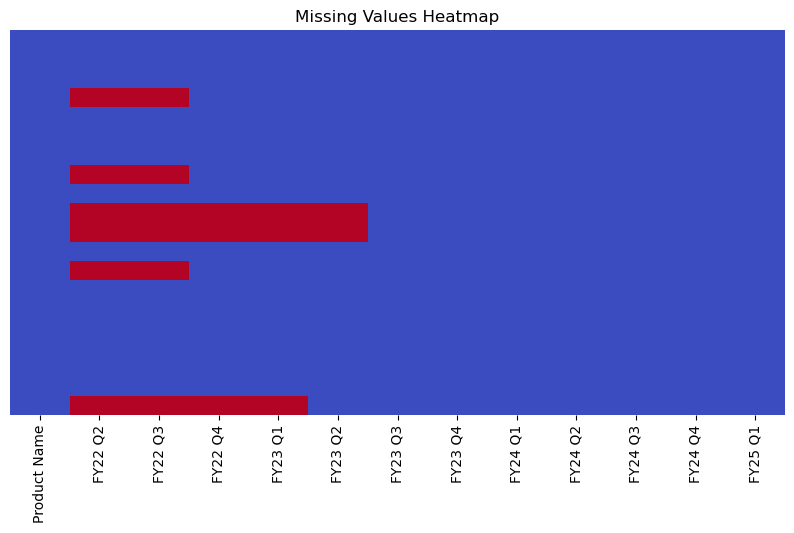

In [82]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values)

# Visualizing missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="coolwarm", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


In [84]:
# Function to get the first quarter when sales started
def first_sale_quarter(row):
    for col in df.columns[1:]:  # Ignore "Product Name" column
        if not pd.isnull(row[col]):  # Find first non-null sales
            return col
    return None  # If all sales are null (unlikely)

# Apply function to find first sale quarter for each product
df["First Sale Quarter"] = df.iloc[:, 1:].apply(first_sale_quarter, axis=1)

# Function to count missing values only before first sale
def count_missing_before_sale(row):
    first_valid_index = row.first_valid_index()  # Get first sale quarter
    if first_valid_index:
        return row.index.get_loc(first_valid_index)  # Count NaNs before first sale
    return len(row)  # If all values are NaN, return total column count

# Apply function on sales columns only
df["Missing Quarters Before Sales"] = df.iloc[:, 1:].apply(count_missing_before_sale, axis=1)

# Display products with delayed sales start
df_missing_analysis = df[["Product Name", "First Sale Quarter", "Missing Quarters Before Sales"]].sort_values(by="Missing Quarters Before Sales", ascending=False)
print(df_missing_analysis.head(20))  # Show top 10


                      Product Name First Sale Quarter  \
9                          SERVER             FY23 Q3   
10                      PROCESSOR             FY23 Q3   
19         SWITCH Enterprise High2            FY23 Q2   
3            SWITCH Enterprise Low            FY22 Q4   
12         TRANSCEIVER MODULE Mid2            FY22 Q4   
7                 ACCESS POINT Mid            FY22 Q4   
0          SWITCH Enterprise High1            FY22 Q2   
1   SWITCH Enterprise Ultra High1             FY22 Q2   
2    SWITCH Enterprise Ultra High2            FY22 Q2   
5                POWER SUPPLY High            FY22 Q2   
6          TRANSCEIVER MODULE High            FY22 Q2   
4          TRANSCEIVER MODULE Mid1            FY22 Q2   
11         SWITCH Data Center High            FY22 Q2   
8                 POWER SUPPLY Mid            FY22 Q2   
14                          MEMORY            FY22 Q2   
13          ROUTER Enterprise Mid1            FY22 Q2   
15          ROUTER Enterprise M

In [86]:
# Summary statistics for numerical columns (sales data only)
df.iloc[:, 1:].describe()


,FY22 Q2,FY22 Q3,FY22 Q4,FY23 Q1,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,Missing Quarters Before Sales
count,14.000000,14.000000,17.000000,17.000000,18.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,56794.714286,51496.142857,45655.882353,33865.235294,29345.666667,23257.800000,29877.350000,25112.350000,25566.100000,27793.350000,30447.550000,27583.350000,1.000000
std,80787.368156,75941.922059,68936.375216,47440.085310,42489.621022,33067.738362,41604.123102,35453.355533,32341.061449,34470.834308,42562.241179,34474.549635,1.747178
min,222.000000,1314.000000,843.000000,531.000000,6.000000,26.000000,111.000000,97.000000,158.000000,138.000000,192.000000,149.000000,0.000000
25%,2910.000000,2923.500000,2981.000000,2956.000000,2589.500000,1581.500000,3192.750000,3432.750000,3476.250000,4104.500000,5778.250000,4321.000000,0.000000
50%,16471.500000,10831.000000,11650.000000,10373.000000,7324.500000,7684.500000,9818.000000,6625.500000,9408.000000,11394.500000,11647.000000,15210.500000,0.000000
75%,58470.000000,65199.250000,52870.000000,38833.000000,29652.000000,26493.500000,39163.250000,30959.500000,34246.250000,40805.000000,30658.750000,33647.250000,2.000000
max,208760.000000,228892.000000,197489.000000,147284.000000,136997.000000,100623.000000,128229.000000,116489.000000,96255.000000,115327.000000,145690.000000,120699.000000,5.000000


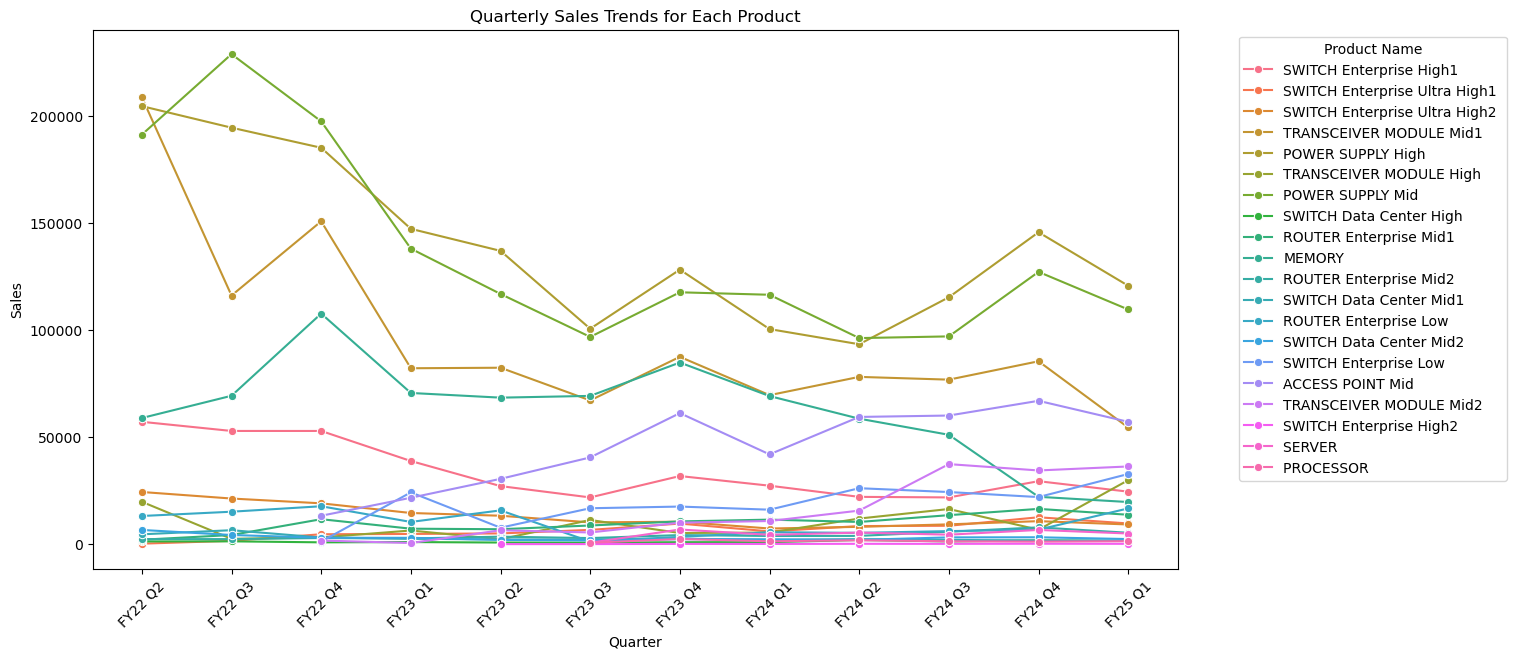

In [7]:
# Ensure all sales columns are numeric (ignoring "Product Name" column)
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")  # Convert to numeric, set errors to NaN

# Convert quarters into long format for visualization
df_melted = df.melt(id_vars=["Product Name"], var_name="Quarter", value_name="Sales")

# Drop rows where sales are NaN (to avoid plotting issues)
df_melted.dropna(subset=["Sales"], inplace=True)

# Plot Sales Trend with Product Name in Legend
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_melted, x="Quarter", y="Sales", hue="Product Name", marker="o")

# Formatting
plt.xticks(rotation=45)
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.title("Quarterly Sales Trends for Each Product")
plt.legend(title="Product Name", bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside
plt.show()


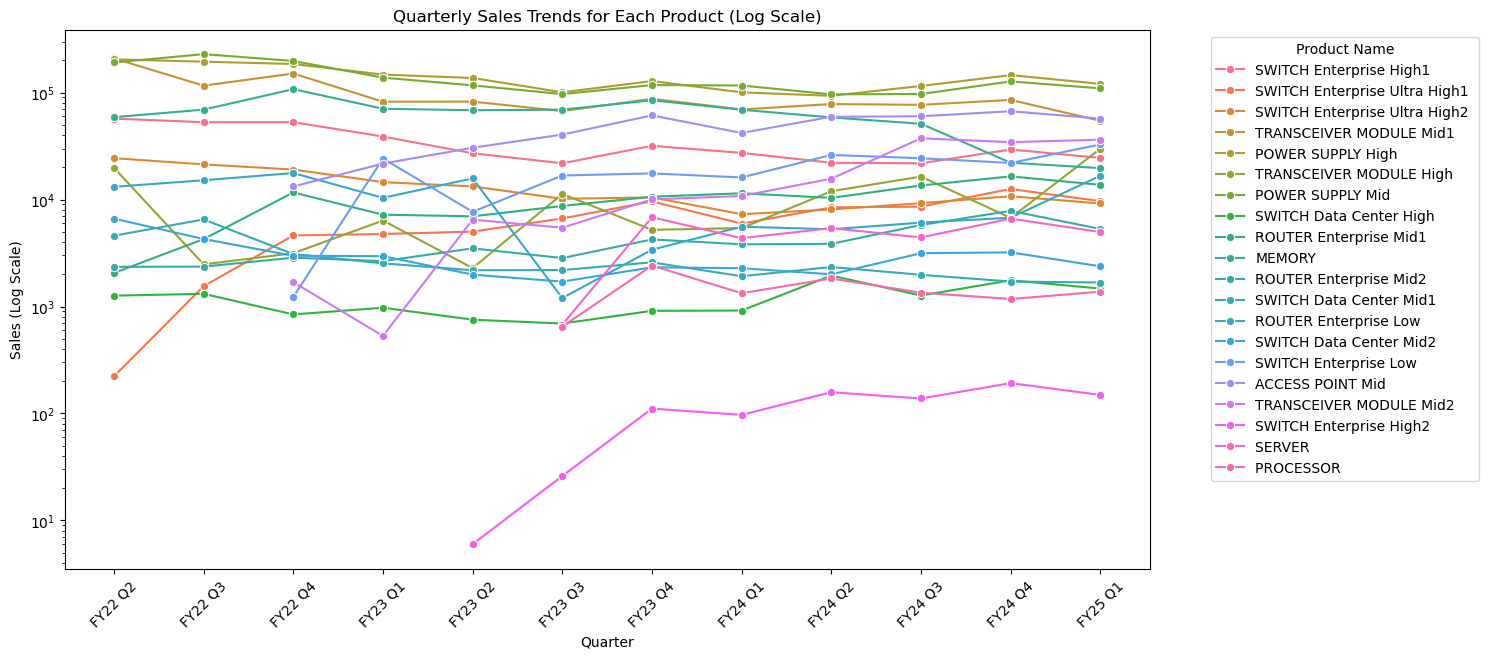

In [9]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=df_melted, x="Quarter", y="Sales", hue="Product Name", marker="o")

plt.xticks(rotation=45)
plt.yscale("log")  # Log scale to handle large differences
plt.xlabel("Quarter")
plt.ylabel("Sales (Log Scale)")
plt.title("Quarterly Sales Trends for Each Product (Log Scale)")
plt.legend(title="Product Name", bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside
plt.show()


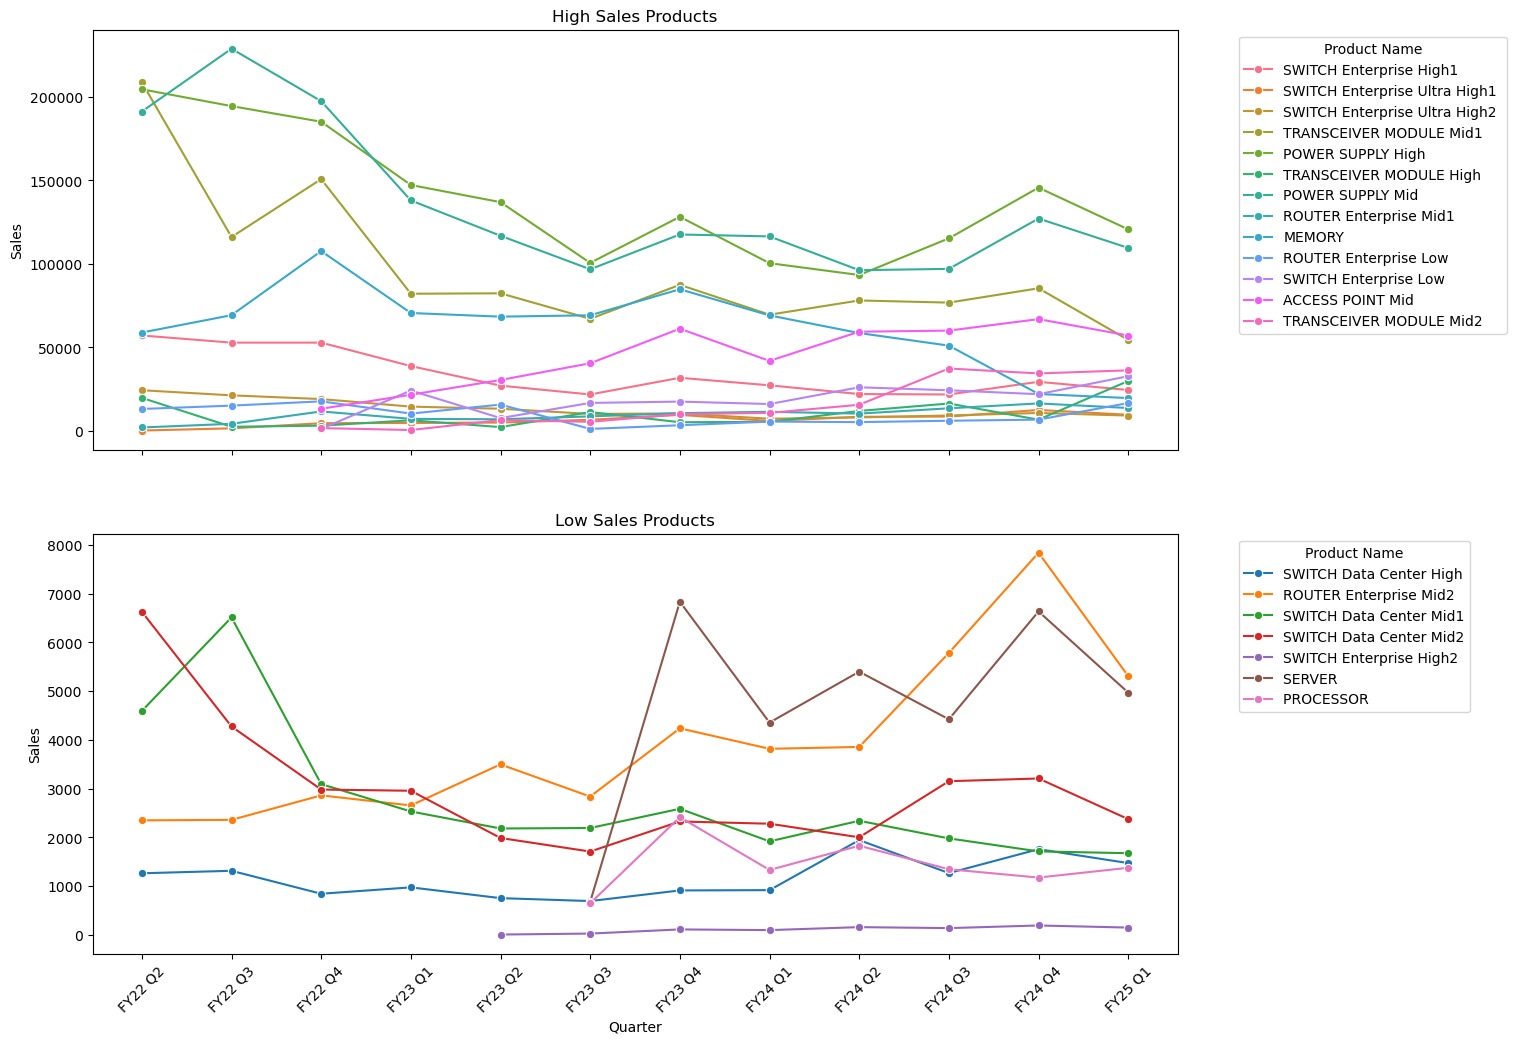

In [11]:
# Define threshold: median sales to separate high and low sales
median_sales = df.iloc[:, 1:].median().median()

# Identify high & low sales products
high_sales = df[df.iloc[:, 1:].max(axis=1) > median_sales]
low_sales = df[df.iloc[:, 1:].max(axis=1) <= median_sales]

# Convert both into long format
df_melted_high = df_melted[df_melted["Product Name"].isin(high_sales["Product Name"])]
df_melted_low = df_melted[df_melted["Product Name"].isin(low_sales["Product Name"])]

fig, ax = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# High Sales Plot
sns.lineplot(data=df_melted_high, x="Quarter", y="Sales", hue="Product Name", marker="o", ax=ax[0])
ax[0].set_title("High Sales Products")
ax[0].legend(title="Product Name", bbox_to_anchor=(1.05, 1), loc='upper left')

# Low Sales Plot
sns.lineplot(data=df_melted_low, x="Quarter", y="Sales", hue="Product Name", marker="o", ax=ax[1])
ax[1].set_title("Low Sales Products")
ax[1].legend(title="Product Name", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.xlabel("Quarter")
plt.show()


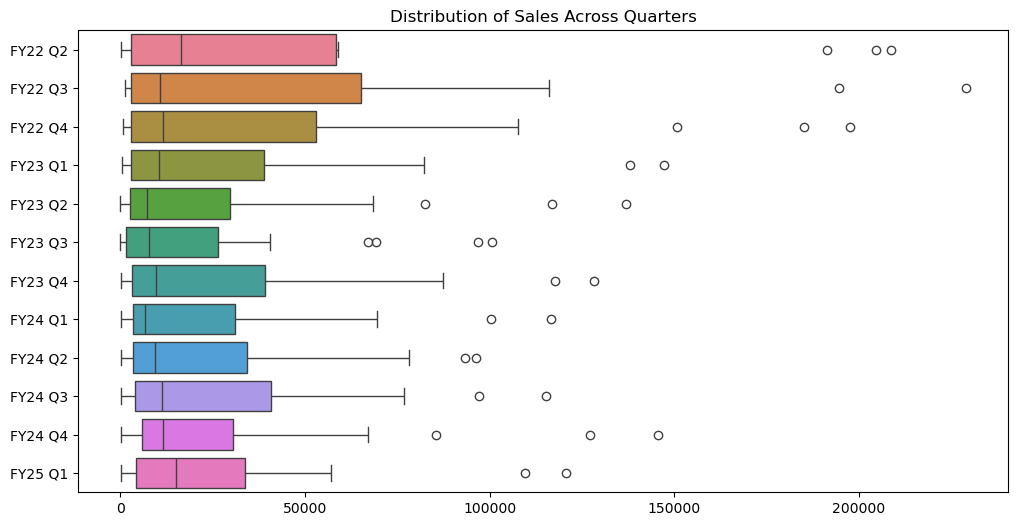

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.iloc[:, 1:], orient="h")
plt.title("Distribution of Sales Across Quarters")
plt.show()


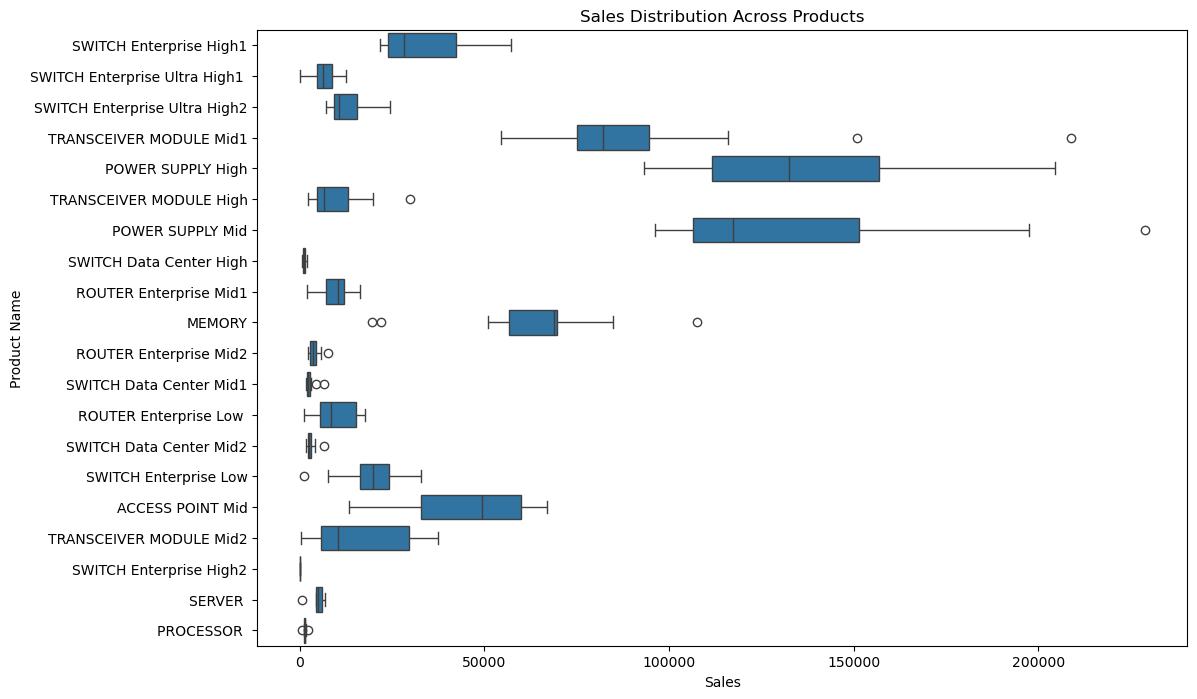

In [15]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_melted, x="Sales", y="Product Name", orient="h")
plt.title("Sales Distribution Across Products")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()


In [18]:
# Summing total sales for each product (excluding NaNs)
df["Total Sales"] = df.iloc[:, 1:].sum(axis=1, skipna=True)

# Top 5 best performing products
top_5 = df.sort_values(by="Total Sales", ascending=False).head(5)
print("Top 5 Products by Sales:\n", top_5[["Product Name", "Total Sales"]])

# Bottom 5 worst performing products
bottom_5 = df.sort_values(by="Total Sales").head(5)
print("Bottom 5 Products by Sales:\n", bottom_5[["Product Name", "Total Sales"]])


Top 5 Products by Sales:
                Product Name  Total Sales
5         POWER SUPPLY High    1672980.0
8          POWER SUPPLY Mid    1633598.0
4   TRANSCEIVER MODULE Mid1    1159374.0
14                   MEMORY     749695.0
7          ACCESS POINT Mid     452656.0
Bottom 5 Products by Sales:
                Product Name  Total Sales
19  SWITCH Enterprise High2        877.0
10               PROCESSOR       10119.0
11  SWITCH Data Center High      14108.0
9                   SERVER       33293.0
16  SWITCH Data Center Mid1      33314.0


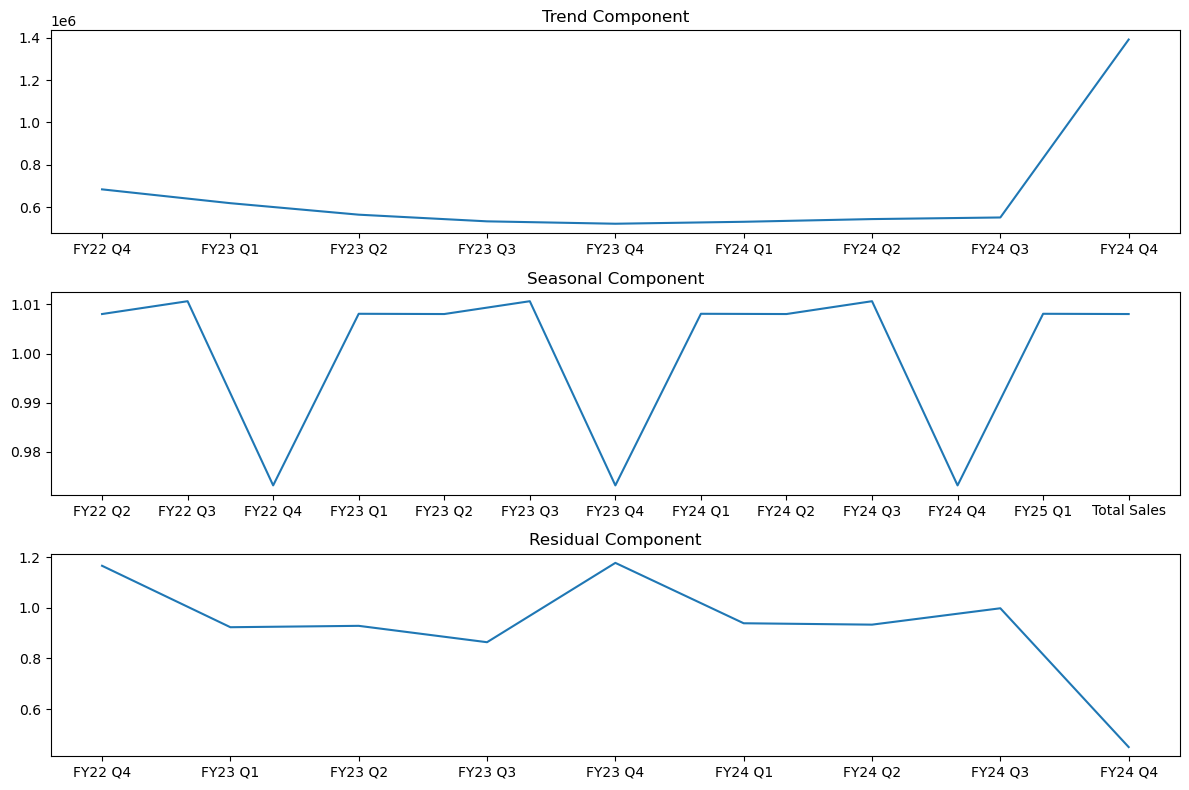

In [20]:
import statsmodels.api as sm

# Group sales data by quarter (ignoring products for now)
df_quarterly_sales = df.iloc[:, 1:].sum().reset_index()
df_quarterly_sales.columns = ["Quarter", "Total Sales"]

# Decompose sales time series to check for trend & seasonality
df_quarterly_sales["Quarter"] = pd.Categorical(df_quarterly_sales["Quarter"], categories=df.columns[1:], ordered=True)
df_quarterly_sales = df_quarterly_sales.sort_values("Quarter")
df_quarterly_sales.set_index("Quarter", inplace=True)

# Apply seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(df_quarterly_sales["Total Sales"], period=4, model="multiplicative")

# Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(decomposition.trend)
plt.title("Trend Component")

plt.subplot(3, 1, 2)
plt.plot(decomposition.seasonal)
plt.title("Seasonal Component")

plt.subplot(3, 1, 3)
plt.plot(decomposition.resid)
plt.title("Residual Component")

plt.tight_layout()
plt.show()


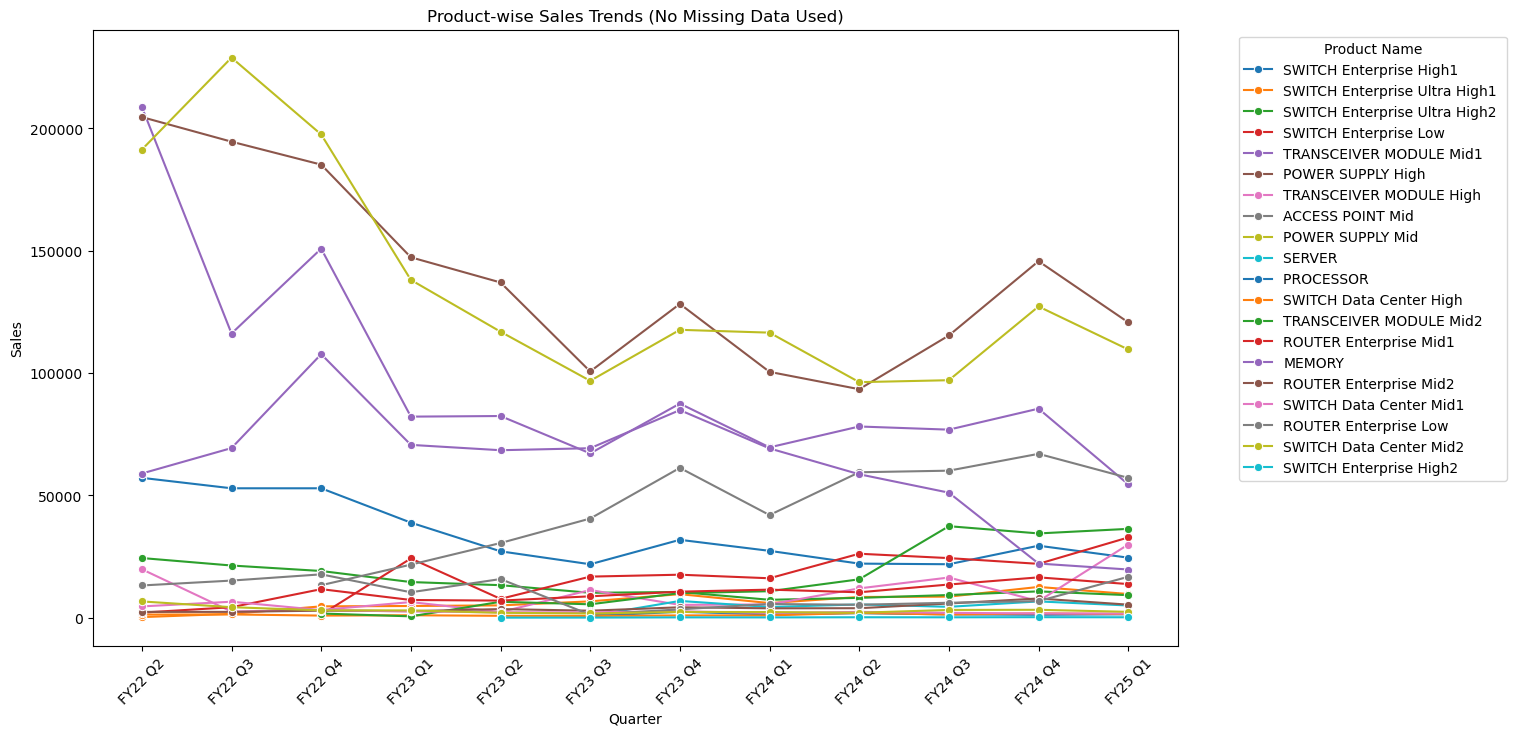

In [22]:
# Create separate trend plots for each product, using only available data
plt.figure(figsize=(14, 8))

for product in df["Product Name"].unique():
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])
    
    # Plot only if product has at least 3 data points
    if len(product_data) > 2:
        sns.lineplot(data=product_data, x="Quarter", y="Sales", label=product, marker="o")

plt.xticks(rotation=45)
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.title("Product-wise Sales Trends (No Missing Data Used)")
plt.legend(title="Product Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


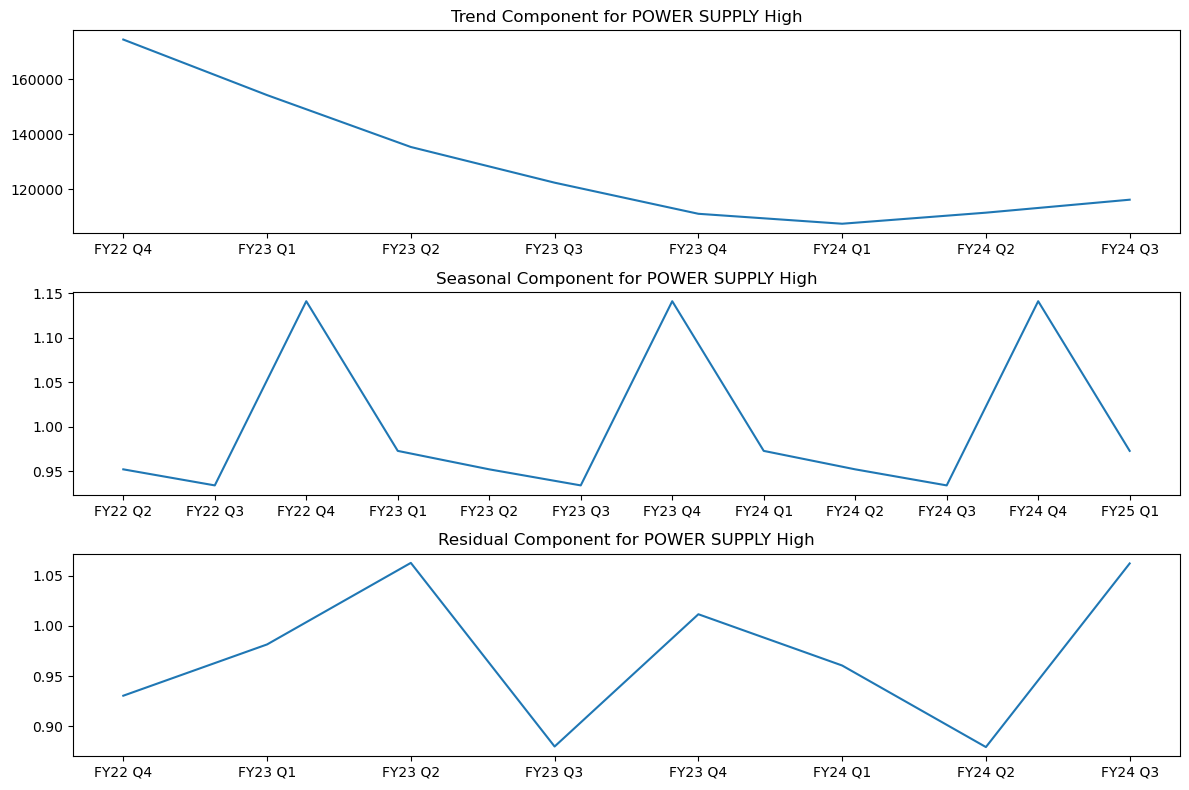

In [24]:
# Select a high-selling product for individual trend analysis
product_name = "POWER SUPPLY High"  # Change to any product name

# Filter data only for this product
product_data = df_melted[df_melted["Product Name"] == product_name].dropna(subset=["Sales"])
product_data.set_index("Quarter", inplace=True)

# Decompose its time series
decomposition = sm.tsa.seasonal_decompose(product_data["Sales"], period=4, model="multiplicative")

# Plot decomposition
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(decomposition.trend)
plt.title(f"Trend Component for {product_name}")

plt.subplot(3, 1, 2)
plt.plot(decomposition.seasonal)
plt.title(f"Seasonal Component for {product_name}")

plt.subplot(3, 1, 3)
plt.plot(decomposition.resid)
plt.title(f"Residual Component for {product_name}")

plt.tight_layout()
plt.show()


Skipping SERVER  (only 7 data points)
Skipping PROCESSOR  (only 7 data points)


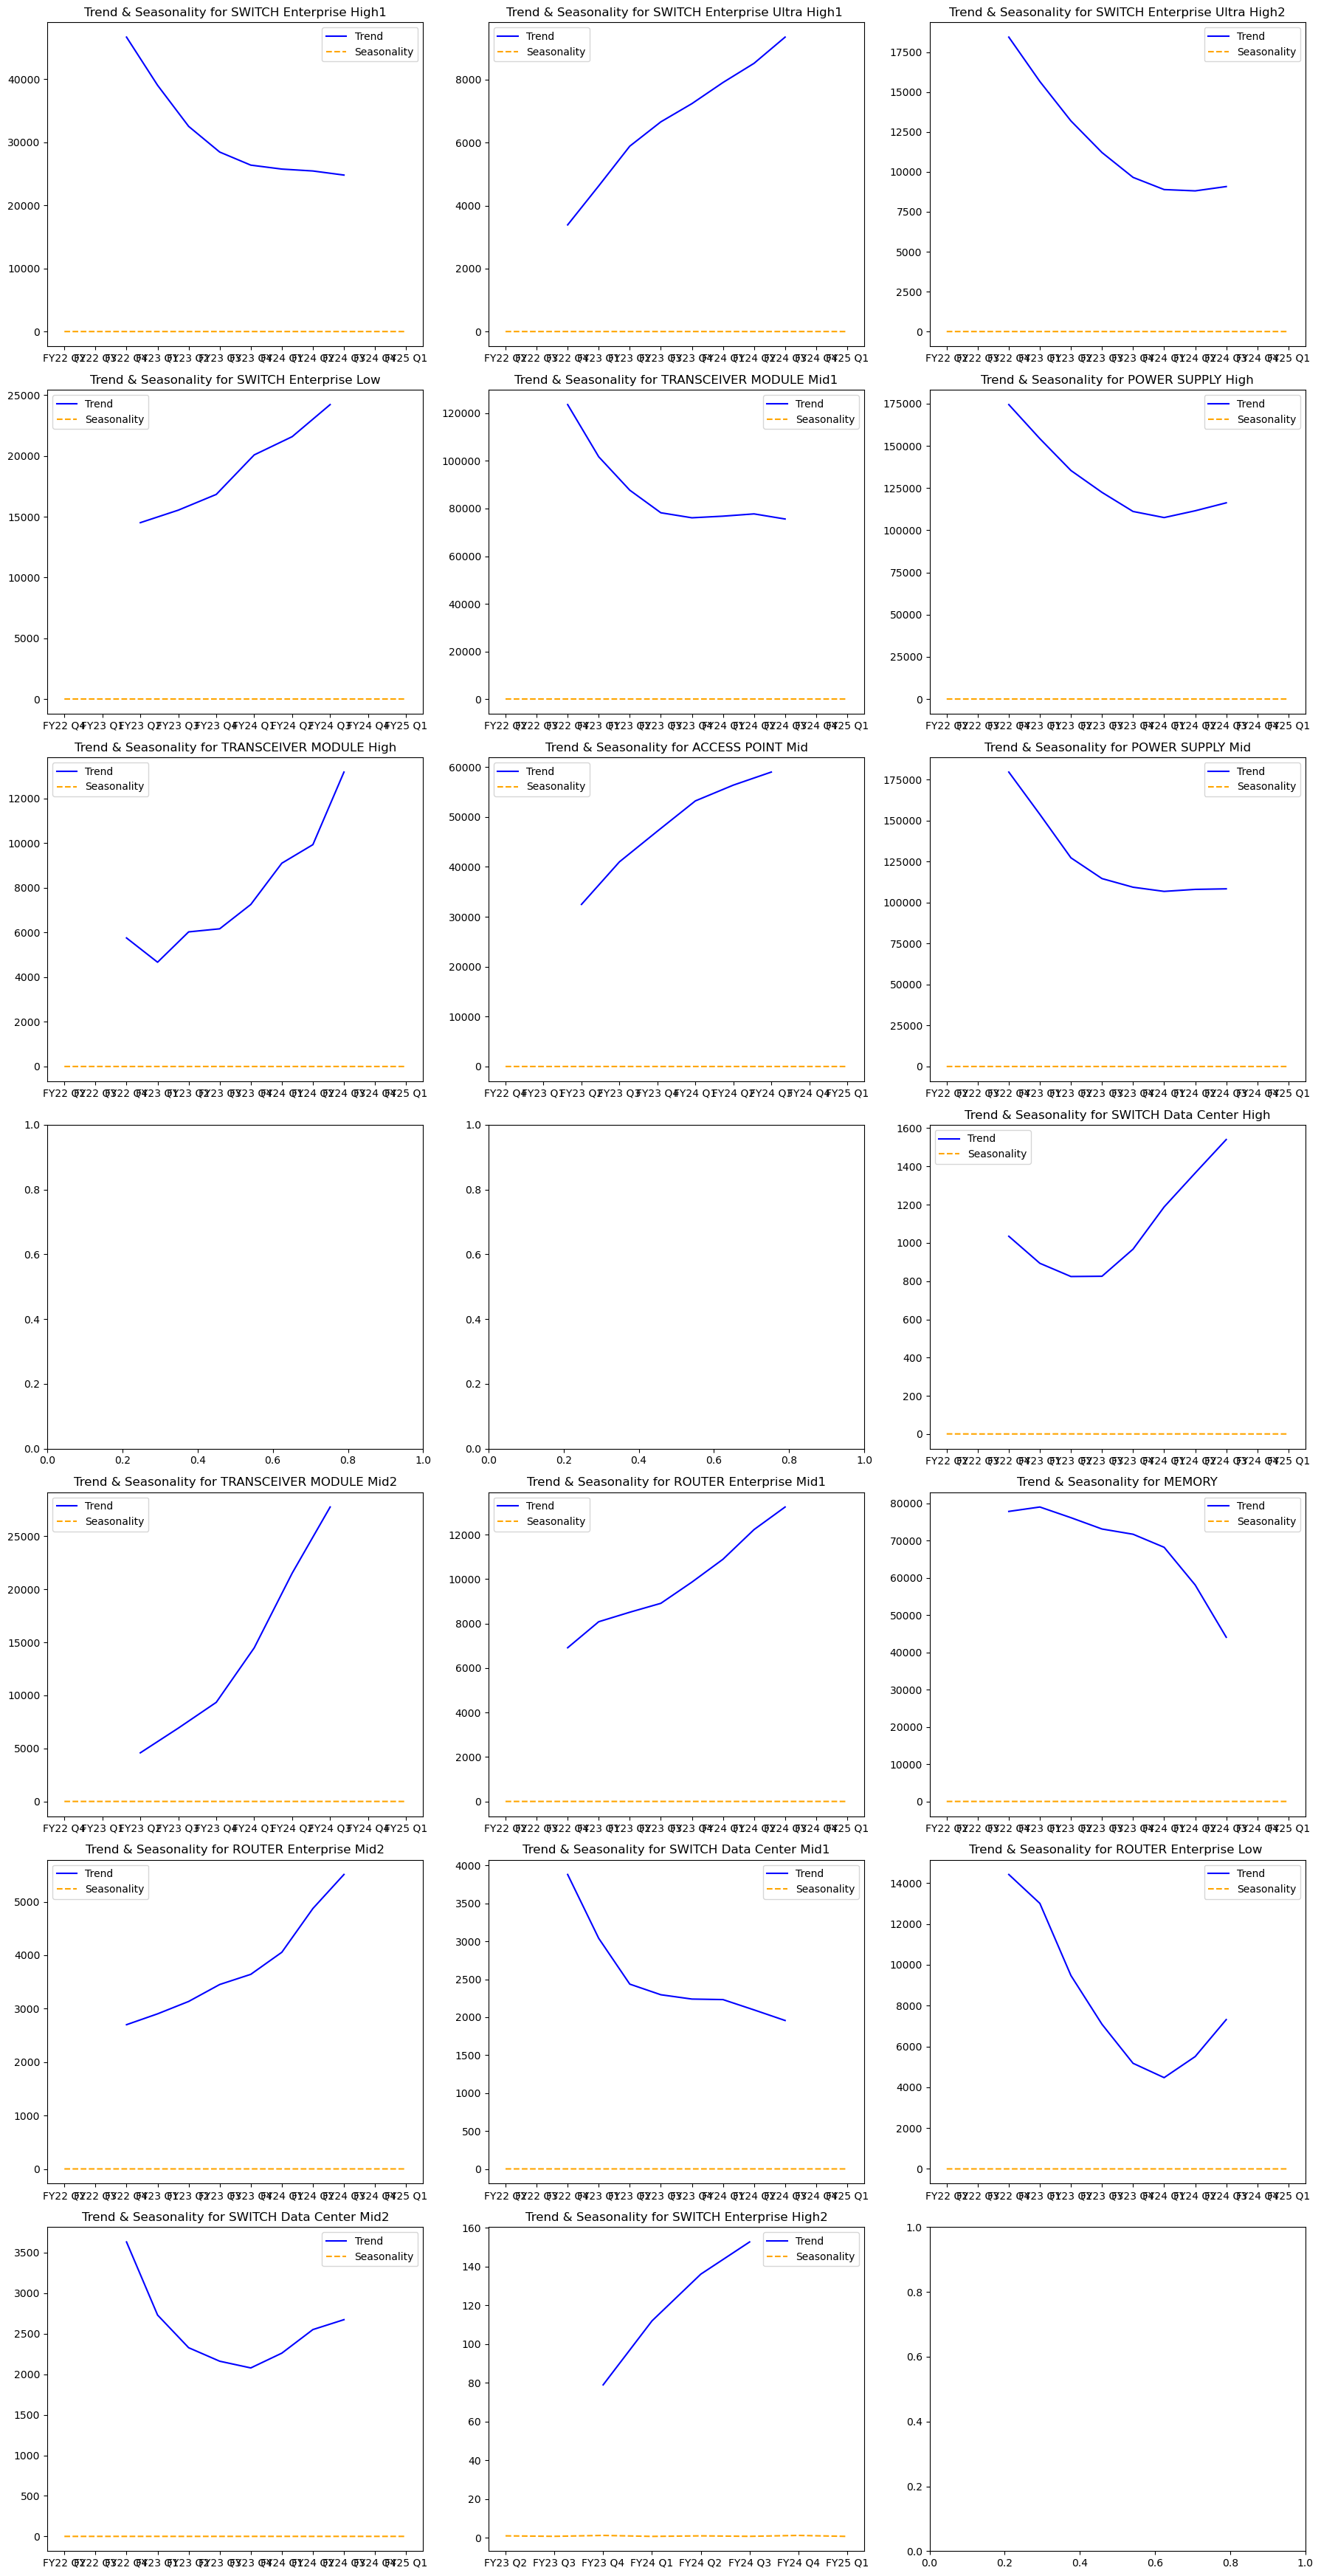

In [32]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure quarters are in correct order
df_melted["Quarter"] = pd.Categorical(df_melted["Quarter"], categories=df.columns[1:], ordered=True)

# List of unique products
products = df["Product Name"].unique()

# Create subplots: 3 per row for readability
num_products = len(products)
fig_rows = (num_products // 3) + 1

fig, axes = plt.subplots(fig_rows, 3, figsize=(18, fig_rows * 5))
axes = axes.flatten()  

for i, product in enumerate(products):
    # Filter data for this product
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])
    
    # Skip products with less than 8 quarters of data (required for seasonality)
    if len(product_data) < 8:
        print(f"Skipping {product} (only {len(product_data)} data points)")
        continue

    # Convert to time series
    product_data.set_index("Quarter", inplace=True)

    # Decompose time series
    decomposition = sm.tsa.seasonal_decompose(product_data["Sales"], period=4, model="multiplicative")

    # Plot trend & seasonality
    axes[i].plot(decomposition.trend, label="Trend", color="blue")
    axes[i].plot(decomposition.seasonal, label="Seasonality", color="orange", linestyle="dashed")
    axes[i].set_title(f"Trend & Seasonality for {product}")
    axes[i].legend()

# Adjust layout
plt.tight_layout()
plt.show()


Skipping SERVER  (only 7 data points)
Skipping PROCESSOR  (only 7 data points)


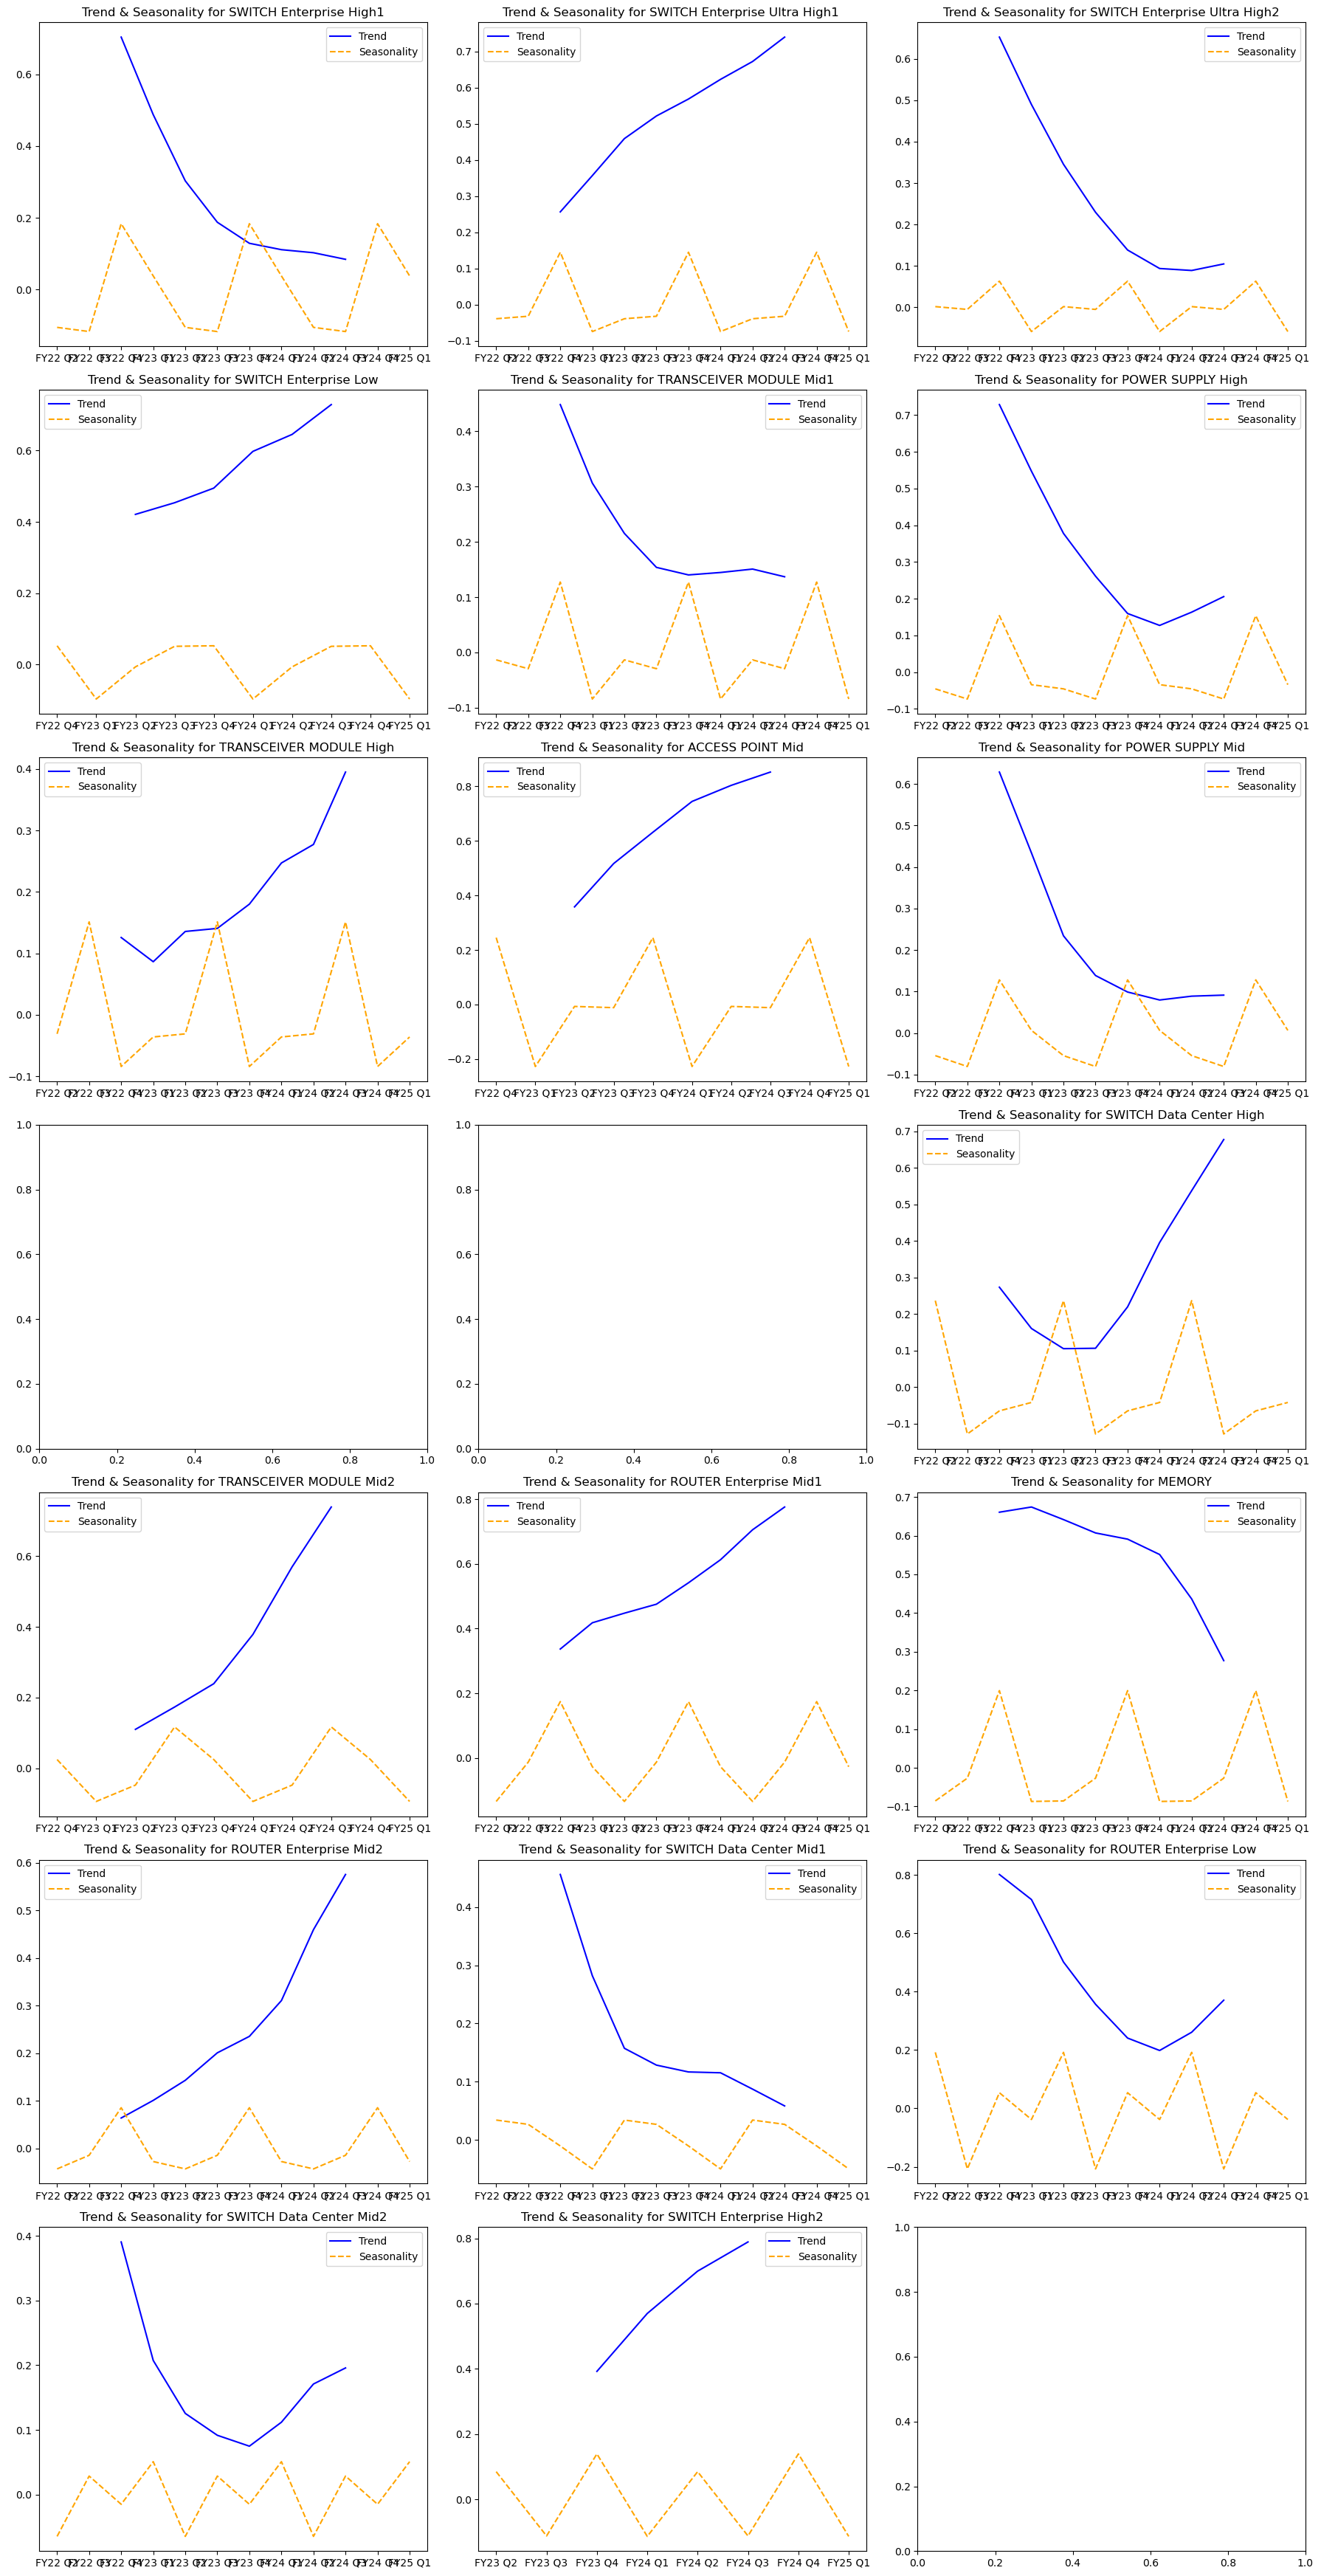

In [28]:

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Ensure quarters are in correct order
df_melted["Quarter"] = pd.Categorical(df_melted["Quarter"], categories=df.columns[1:], ordered=True)

# List of unique products
products = df["Product Name"].unique()

# Create subplots: 3 per row for readability
num_products = len(products)
fig_rows = (num_products // 3) + 1

fig, axes = plt.subplots(fig_rows, 3, figsize=(18, fig_rows * 5))
axes = axes.flatten()  

for i, product in enumerate(products):
    # Filter data for this product
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])
    
    # Skip products with less than 8 quarters of data
    if len(product_data) < 8:
        print(f"Skipping {product} (only {len(product_data)} data points)")
        continue

    # Normalize sales using MinMaxScaler (scales between 0 and 1)
    scaler = MinMaxScaler()
    product_data["Sales"] = scaler.fit_transform(product_data[["Sales"]])

    # Convert to time series
    product_data.set_index("Quarter", inplace=True)

    # Use ADDITIVE model to avoid zero-value issues
    decomposition = sm.tsa.seasonal_decompose(product_data["Sales"], period=4, model="additive")

    # Plot trend & seasonality
    axes[i].plot(decomposition.trend, label="Trend", color="blue")
    axes[i].plot(decomposition.seasonal, label="Seasonality", color="orange", linestyle="dashed")
    axes[i].set_title(f"Trend & Seasonality for {product}")
    axes[i].legend()

# Adjust layout
plt.tight_layout()
plt.show()


Checking seasonality for SERVER  using lag plot


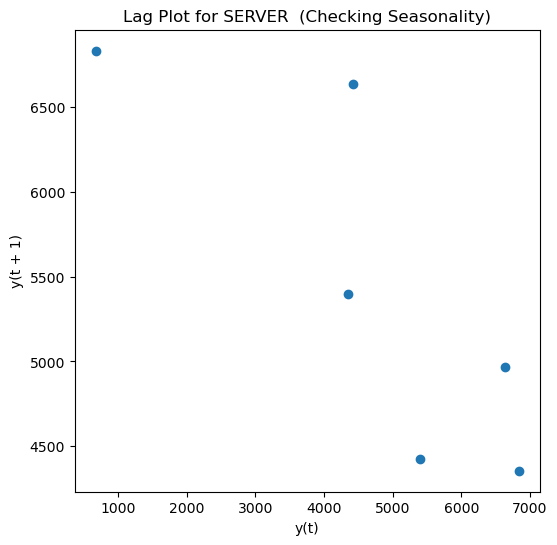

Checking seasonality for PROCESSOR  using lag plot


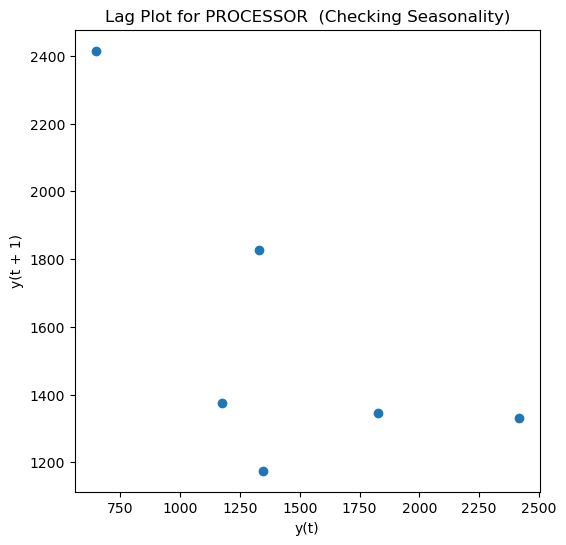

In [116]:
from pandas.plotting import lag_plot

for product in products:
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])

    # If product has 7 data points, check seasonality with a lag plot
    if len(product_data) == 7:
        print(f"Checking seasonality for {product} using lag plot")
        plt.figure(figsize=(6, 6))
        lag_plot(product_data["Sales"])
        plt.title(f"Lag Plot for {product} (Checking Seasonality)")
        plt.show()


Using rolling average for SERVER 


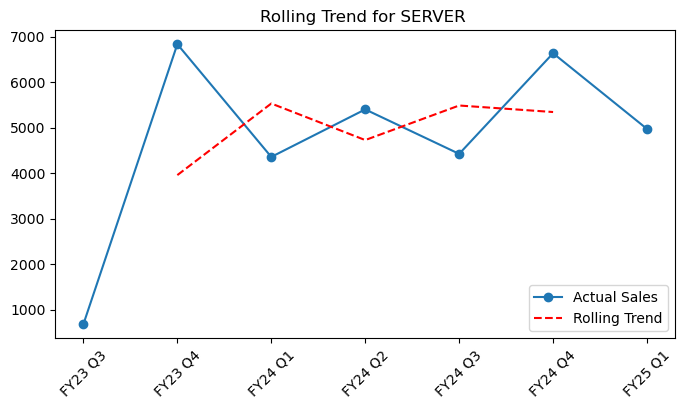

Using rolling average for PROCESSOR 


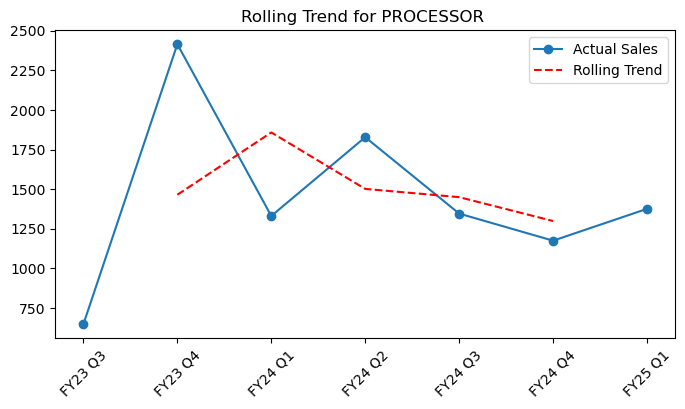

In [119]:
for product in products:
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])

    # If product has 7 data points, use a rolling average instead of decomposition
    if len(product_data) == 7:
        print(f"Using rolling average for {product}")
        product_data["Rolling_Trend"] = product_data["Sales"].rolling(window=3, center=True).mean()

        # Plot trend manually
        plt.figure(figsize=(8, 4))
        plt.plot(product_data["Quarter"], product_data["Sales"], marker="o", label="Actual Sales")
        plt.plot(product_data["Quarter"], product_data["Rolling_Trend"], linestyle="dashed", color="red", label="Rolling Trend")
        plt.xticks(rotation=45)
        plt.title(f"Rolling Trend for {product}")
        plt.legend()
        plt.show()


In [34]:
import pandas as pd

def convert_fy_quarter_to_datetime(fy_quarter):
    """Convert 'FY22 Q2' to a datetime format (first day of the quarter)."""
    try:
        # Ensure the value is a valid quarter format
        if not isinstance(fy_quarter, str) or not fy_quarter.startswith("FY"):
            return pd.NaT  # Return NaT for invalid/missing values

        fy, quarter = fy_quarter.split(" ")  # Split "FY22 Q2" → ["FY22", "Q2"]
        year = 2000 + int(fy[2:])  # Convert "FY22" → 2022

        # Map quarters to starting month
        quarter_month = {"Q1": "01", "Q2": "04", "Q3": "07", "Q4": "10"}

        return pd.to_datetime(f"{year}-{quarter_month.get(quarter, '01')}-01")  # Convert to YYYY-MM-DD

    except Exception as e:
        print(f"⚠ Error converting '{fy_quarter}': {str(e)}")
        return pd.NaT  # Return NaT for errors

# Apply conversion to the 'Quarter' column
df_melted["Quarter"] = df_melted["Quarter"].apply(convert_fy_quarter_to_datetime)

# Verify the transformation
print(df_melted.head())


                     Product Name    Quarter     Sales
0         SWITCH Enterprise High1 2022-04-01   57147.0
1  SWITCH Enterprise Ultra High1  2022-04-01     222.0
2   SWITCH Enterprise Ultra High2 2022-04-01   24362.0
4         TRANSCEIVER MODULE Mid1 2022-04-01  208760.0
5               POWER SUPPLY High 2022-04-01  204604.0


In [36]:
import statsmodels.api as sm

# Forecast for each product separately
forecast_results = {}

for product in df["Product Name"].unique():
    product_data = df_melted[df_melted["Product Name"] == product]

    # Find the first quarter where sales are not missing
    first_valid_index = product_data["Sales"].first_valid_index()
    if first_valid_index is None:
        continue  # Skip products with all missing data

    # Train model only on available data (ignore missing start)
    product_data = product_data.loc[first_valid_index:]

    # Ensure we have at least 8 data points
    if len(product_data) >= 8:
        print(f"Forecasting for {product} (training from {product_data.iloc[0]['Quarter']})...")

        # Fit SARIMA model (p, d, q) (P, D, Q, s)
        sarima_model = sm.tsa.statespace.SARIMAX(
            product_data["Sales"], 
            order=(1, 1, 1), 
            seasonal_order=(1, 1, 1, 4),  # Quarterly data
            enforce_stationarity=False, 
            enforce_invertibility=False
        ).fit()

        # Forecast next quarter (FY25 Q2)
        forecast = sarima_model.get_forecast(steps=1)
        forecast_value = forecast.predicted_mean.iloc[0]

        # Store result (ensure no negatives)
        forecast_results[product] = max(0, round(forecast_value, 2))

# Print forecasted values
print("\nAdjusted Forecasted Sales for FY25 Q2 (Only Using Available Data):")
for product, value in forecast_results.items():
    print(f"{product}: {value}")


Forecasting for SWITCH Enterprise High1 (training from 2022-04-01 00:00:00)...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.44099D-01    |proj g|=  5.14916D-02

At iterate    5    f=  7.42405D-01    |proj g|=  5.46246D-05

At iterate   10    f=  7.42402D-01    |proj g|=  1.62318D-03

At iterate   15    f=  7.42386D-01    |proj g|=  1.77350D-04

At iterate   20    f=  7.42363D-01    |proj g|=  1.26179D-03

At iterate   25    f=  7.42319D-01    |proj g|=  4.14965D-03

At iterate   30    f=  7.42238D-01    |proj g|=  4.66101D-04

At iterate   35    f=  7.42187D-01    |proj g|=  2.43545D-04

At iterate   40    f=  7.42138D-01    |proj g|=  1.46210D-03

At iterate   45    f=  7.42089D-01    |proj g|=  6.74496D-04

At iterate   50    f=  7.42026D-01    |proj g|=  1.91277D-03

           * * *

Tit   = total number of iterations
Tnf   = total numb

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/ho

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.48154D-01    |proj g|=  6.78234D-01

At iterate    5    f=  6.32615D-01    |proj g|=  3.36526D-03

At iterate   10    f=  6.32532D-01    |proj g|=  1.05548D-04

At iterate   15    f=  6.32459D-01    |proj g|=  4.08616D-03

At iterate   20    f=  6.20562D-01    |proj g|=  6.87179D-02

At iterate   25    f=  5.19143D-01    |proj g|=  6.59489D-01
  ys=-5.815E-03  -gs= 2.433E-02 BFGS update SKIPPED

At iterate   30    f=  4.08476D-01    |proj g|=  2.53626D+01

At iterate   35    f=  3.58075D-01    |proj g|=  3.85462D+01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of 

 This problem is unconstrained.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported inde


At iterate   35    f=  6.93010D-01    |proj g|=  5.38166D-03

At iterate   40    f=  6.92823D-01    |proj g|=  5.47693D-03

At iterate   45    f=  6.92547D-01    |proj g|=  3.01227D-03

At iterate   50    f=  6.92161D-01    |proj g|=  1.84603D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50     77      1     0     0   1.846D-02   6.922D-01
  F =  0.69216071113904609     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
Forecasting for SWITCH Enterprise Low (training from 2022-10-01 00:00:00)...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M

...

 This problem is unconstrained.



At iterate   25    f=  6.96098D-01    |proj g|=  2.94810D-03

At iterate   30    f=  6.95994D-01    |proj g|=  5.42077D-03

At iterate   35    f=  6.95908D-01    |proj g|=  7.24966D-03

At iterate   40    f=  6.95651D-01    |proj g|=  6.12128D-03

At iterate   45    f=  6.95491D-01    |proj g|=  1.53550D-02

At iterate   50    f=  6.94164D-01    |proj g|=  7.48335D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50     81      1     0     0   7.483D-02   6.942D-01
  F =  0.69416434724308484     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
Forecasting for SWITCH Data Center Mid1 (training f

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/s39dhi/anaconda3/lib/py


At iterate   30    f=  6.01147D-01    |proj g|=  1.53813D-04

At iterate   35    f=  6.00852D-01    |proj g|=  7.29264D-03

At iterate   40    f=  6.00080D-01    |proj g|=  8.01584D-03

At iterate   45    f=  5.99433D-01    |proj g|=  8.07405D-03

At iterate   50    f=  5.97752D-01    |proj g|=  1.08690D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50     75      1     0     0   1.087D-02   5.978D-01
  F =  0.59775178183226207     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
Forecasting for ROUTER Enterprise Low  (training from 2022-04-01 00:00:00)...
RUNNING THE L-BFGS-B CODE

        

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/s39dhi/anaconda3/lib/py

In [64]:
# Load Product Life Cycle data
product_lifecycle = pd.read_csv("ciso.csv")  # Replace with actual filename

# Merge with forecast results
forecast_df = pd.DataFrame(forecast_results.items(), columns=["Product Name", "Forecasted Sales"])
forecast_df = forecast_df.merge(product_lifecycle, on="Product Name", how="left")

# Display merged results
print(forecast_df)



Empty DataFrame
Columns: [Product Name, Forecasted Sales, Product Life Cycle, FY22 Q2, FY22 Q3, FY22 Q4, FY23 Q1, FY23 Q2, FY23 Q3, FY23 Q4, FY24 Q1, FY24 Q2, FY24 Q3, FY24 Q4, FY25 Q1]
Index: []


In [62]:
# Split data into categories
sustaining_products = forecast_df[forecast_df["Product Life Cycle"] == "Sustaining"]
declining_products = forecast_df[forecast_df["Product Life Cycle"] == "Decline"]
npi_products = forecast_df[forecast_df["Product Life Cycle"] == "NPI"]

print(f"Sustaining: {len(sustaining_products)} products")
print(f"Declining: {len(declining_products)} products")
print(f"NPI: {len(npi_products)} products")


KeyError: 'Product Life Cycle'

In [44]:
import statsmodels.api as sm
import numpy as np

for product in sustaining_products["Product Name"]:
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])
    
    if len(product_data) >= 8:
        print(f"Forecasting for {product}...")

        try:
            sarima_model = sm.tsa.statespace.SARIMAX(
                product_data["Sales"], 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 4),
                enforce_stationarity=False, 
                enforce_invertibility=False
            ).fit(disp=False)

            forecast = sarima_model.get_forecast(steps=1)
            forecast_value = forecast.predicted_mean.iloc[0]

            forecast_results[product] = max(0, round(forecast_value, 2))

        except (np.linalg.LinAlgError, ValueError) as e:
            print(f"⚠ SARIMA failed for {product} ({str(e)}). Using Moving Average instead.")
            fallback_forecast = product_data["Sales"].rolling(window=3, min_periods=1).mean().iloc[-1]
            forecast_results[product] = max(0, round(fallback_forecast, 2))

print("\nFinal Adjusted Forecast for FY25 Q2:")
for product, value in forecast_results.items():
    print(f"{product}: {value}")



Final Adjusted Forecast for FY25 Q2:


In [46]:
forecast_df = pd.DataFrame(forecast_results.items(), columns=["Product Name", "Forecasted Sales"])
forecast_df["Quarter"] = "FY25 Q2"  # Assign proper quarter label

print("\nFinal Forecast for FY25 Q2:")
print(forecast_df)



Final Forecast for FY25 Q2:
Empty DataFrame
Columns: [Product Name, Forecasted Sales, Quarter]
Index: []


In [48]:
import numpy as np
from scipy.optimize import curve_fit

for product in declining_products["Product Name"]:
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])
    
    if len(product_data) >= 8:
        print(f"Forecasting for {product} (Declining Product)...")

        try:
            # Fit exponential decay model: y = a * e^(-bx)
            x = np.arange(len(product_data))
            y = product_data["Sales"].values
            
            # Add bounds to prevent extreme values of a and b
            popt, _ = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, y, maxfev=10000, bounds=([0, 0], [np.inf, 1]))
            
            a, b = popt
            forecast_value = a * np.exp(-b * (len(product_data) + 1))

            forecast_results[product] = max(0, round(forecast_value, 2))

        except (RuntimeError, ValueError, OverflowError) as e:
            print(f"⚠ Exponential decay failed for {product} ({str(e)}). Using Moving Average instead.")
            fallback_forecast = product_data["Sales"].rolling(window=3, min_periods=1).mean().iloc[-1]
            forecast_results[product] = max(0, round(fallback_forecast, 2))


In [50]:
from prophet import Prophet

for product in npi_products["Product Name"]:
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])

    if len(product_data) >= 8:
        print(f"Forecasting for {product} (NPI Product)...")

        try:
            prophet_df = product_data.rename(columns={"Quarter": "ds", "Sales": "y"})

            # Fit Prophet model
            model = Prophet(seasonality_mode="multiplicative")
            model.fit(prophet_df)

            # Predict next quarter
            future = model.make_future_dataframe(periods=1, freq="Q")
            forecast = model.predict(future)
            forecast_value = forecast.iloc[-1]["yhat"]

            forecast_results[product] = max(0, round(forecast_value, 2))

        except Exception as e:
            print(f"⚠ Prophet failed for {product} ({str(e)}). Using Moving Average instead.")
            fallback_forecast = product_data["Sales"].rolling(window=3, min_periods=1).mean().iloc[-1]
            forecast_results[product] = max(0, round(fallback_forecast, 2))


In [52]:
!pip install prophet


In [54]:
forecast_df = pd.DataFrame(forecast_results.items(), columns=["Product Name", "Forecasted Sales"])
forecast_df["Quarter"] = "FY25 Q2"  # Assign proper quarter label

print("\nFinal Forecast for FY25 Q2:")
print(forecast_df)



Final Forecast for FY25 Q2:
Empty DataFrame
Columns: [Product Name, Forecasted Sales, Quarter]
Index: []


In [56]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Identify products with only 7 data points
for product in df["Product Name"].unique():
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])

    if len(product_data) == 7:  # Only 7 quarters available
        print(f"⚠ {product} has only 7 quarters of data. Using Linear Regression.")

        # Convert quarters to numeric indices
        product_data["Quarter_Index"] = np.arange(1, 8).reshape(-1, 1)

        # Fit a Linear Regression Model
        model = LinearRegression()
        model.fit(product_data["Quarter_Index"].values.reshape(-1, 1), product_data["Sales"].values)

        # Predict FY25Q2 (Quarter 8)
        forecast_value = model.predict([[8]])[0]
        forecast_results[product] = max(0, round(forecast_value, 2))


In [58]:
# Convert forecast results to DataFrame
forecast_df = pd.DataFrame(forecast_results.items(), columns=["Product Name", "Forecasted Sales"])
forecast_df["Quarter"] = "FY25 Q2"  # Assign correct quarter

# Display the complete forecast
print("\nFinal Forecast for FY25 Q2 (All Products Included):")
print(forecast_df)



Final Forecast for FY25 Q2 (All Products Included):
Empty DataFrame
Columns: [Product Name, Forecasted Sales, Quarter]
Index: []


In [60]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit

# ✅ Step 1: Convert 'Quarter' to datetime (ignore missing start values)
def convert_fy_quarter_to_datetime(fy_quarter):
    """Convert 'FY22 Q2' to datetime format (first day of the quarter)."""
    try:
        if not isinstance(fy_quarter, str) or not fy_quarter.startswith("FY"):
            return pd.NaT  # Return NaT for invalid/missing values
        fy, quarter = fy_quarter.split(" ")  # Split "FY22 Q2" → ["FY22", "Q2"]
        year = 2000 + int(fy[2:])  # Convert "FY22" → 2022
        quarter_month = {"Q1": "01", "Q2": "04", "Q3": "07", "Q4": "10"}  # Quarter mapping
        return pd.to_datetime(f"{year}-{quarter_month.get(quarter, '01')}-01")  # Convert to date
    except Exception:
        return pd.NaT  # Return NaT for errors

df_melted["Quarter"] = df_melted["Quarter"].apply(convert_fy_quarter_to_datetime)
df_melted = df_melted.dropna(subset=["Quarter"])  # Drop rows where quarter conversion failed

# ✅ Step 2: Merge Product Life Cycle Data
product_lifecycle = pd.read_csv("ciso.csv")  # Load product life cycle data
df_melted = df_melted.merge(product_lifecycle, on="Product Name", how="left")

# ✅ Step 3: Prepare Product Categories
sustaining_products = df_melted[df_melted["Product Life Cycle"] == "Sustaining"]
declining_products = df_melted[df_melted["Product Life Cycle"] == "Decline"]
npi_products = df_melted[df_melted["Product Life Cycle"] == "NPI"]

forecast_results = {}

# ✅ Step 4: Forecast for Each Product Based on Category
for product in df["Product Name"].unique():
    product_data = df_melted[df_melted["Product Name"] == product].dropna(subset=["Sales"])
    
    if product_data.empty:
        print(f"⚠ Skipping {product}: No sales data found.")
        continue
    
    # Ignore missing values at the start (train only on available data)
    first_valid_index = product_data["Sales"].first_valid_index()
    product_data = product_data.loc[first_valid_index:]

    if len(product_data) >= 8:
        # 🔹 **Sustaining Products → SARIMA**
        if product in sustaining_products["Product Name"].values:
            try:
                sarima_model = sm.tsa.statespace.SARIMAX(
                    product_data["Sales"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 4)
                ).fit(disp=False)
                forecast = sarima_model.get_forecast(steps=1)
                forecast_value = forecast.predicted_mean.iloc[0]
                forecast_results[product] = max(0, round(forecast_value, 2))
            except:
                print(f"⚠ SARIMA failed for {product}. Using Moving Average instead.")
                forecast_results[product] = max(0, round(product_data["Sales"].rolling(3).mean().iloc[-1], 2))

        # 🔹 **Declining Products → Exponential Decay or Linear Regression**
        elif product in declining_products["Product Name"].values:
            try:
                x = np.arange(len(product_data))
                y = product_data["Sales"].values
                popt, _ = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, y, bounds=([0, 0], [np.inf, 1]))
                a, b = popt
                forecast_value = a * np.exp(-b * (len(product_data) + 1))
                forecast_results[product] = max(0, round(forecast_value, 2))
            except:
                print(f"⚠ Exponential Decay failed for {product}. Using Linear Regression instead.")
                model = LinearRegression()
                x = np.arange(len(product_data)).reshape(-1, 1)
                model.fit(x, y)
                forecast_value = model.predict([[len(product_data) + 1]])[0]
                forecast_results[product] = max(0, round(forecast_value, 2))

        # 🔹 **NPI Products → Prophet**
        elif product in npi_products["Product Name"].values:
            try:
                prophet_df = product_data.rename(columns={"Quarter": "ds", "Sales": "y"})
                prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])  # Ensure datetime format
                model = Prophet(seasonality_mode="multiplicative")
                model.fit(prophet_df)
                future = model.make_future_dataframe(periods=1, freq="Q")
                forecast = model.predict(future)
                forecast_value = forecast.iloc[-1]["yhat"]
                forecast_results[product] = max(0, round(forecast_value, 2))
            except:
                print(f"⚠ Prophet failed for {product}. Using Moving Average instead.")
                forecast_results[product] = max(0, round(product_data["Sales"].rolling(3).mean().iloc[-1], 2))

    # 🔹 **Handle Products with 7 Quarters (Fallback to Linear Regression)**
    elif len(product_data) == 7:
        print(f"⚠ {product} has only 7 quarters. Using Linear Regression.")
        x = np.arange(1, 8).reshape(-1, 1)
        y = product_data["Sales"].values
        model = LinearRegression()
        model.fit(x, y)
        forecast_value = model.predict([[8]])[0]
        forecast_results[product] = max(0, round(forecast_value, 2))

# ✅ Step 5: Format and Print Final Forecast
forecast_df = pd.DataFrame(forecast_results.items(), columns=["Product Name", "Forecasted Sales"])
forecast_df["Quarter"] = "FY25 Q2"

print("\nFinal Forecast for FY25 Q2 (All Products Included):")
print(forecast_df)


KeyError: 'Product Life Cycle'

In [9]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("forecasted_values.csv")

# Extract relevant columns
actual_columns = ['FY24_Q3', 'FY24_Q4', 'FY25_Q1']
forecast_columns = [col for col in df.columns if 'Forecasted' in col]

# ARIMA Model
actual_sales = df[actual_columns].mean(axis=0)  # Aggregating across products
actual_sales.index = pd.date_range(start="2023-Q3", periods=len(actual_sales), freq='Q')  # Assigning proper index

stepwise_model = auto_arima(actual_sales, seasonal=False, trace=True, suppress_warnings=True, d=1, D=0, max_p=3, max_q=3)
arima_forecast = stepwise_model.predict(n_periods=1)
print(f"ARIMA Forecast for FY25_Q2: {arima_forecast.flatten()[0]}")

# Prepare data for XGBoost
features = df[actual_columns + forecast_columns]
target = df['FY25_Q1']  # Using last available actual sales as target
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict FY25_Q2 sales
xgb_forecast = xgb_model.predict(features.iloc[-1:].drop(columns=['FY25_Q1']))
print(f"XGBoost Forecast for FY25_Q2: {xgb_forecast[0]}")

# Model Evaluation
xgb_predictions = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, xgb_predictions)
print(f"XGBoost MAE: {mae}")

# Plot ARIMA and XGBoost Predictions
plt.figure(figsize=(8, 5))
plt.plot(actual_sales.index, actual_sales.values, label='Actual Sales', marker='o')
plt.axvline(x=len(actual_sales), color='r', linestyle='--', label='Forecast Start')
plt.scatter([actual_sales.index[-1] + pd.DateOffset(months=3)], arima_forecast, color='blue', label='ARIMA Forecast', marker='x', s=100)
plt.scatter([actual_sales.index[-1] + pd.DateOffset(months=3)], xgb_forecast, color='green', label='XGBoost Forecast', marker='D', s=100)
plt.legend()
plt.title("FY25_Q2 Forecast: ARIMA vs XGBoost")
plt.show()


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=41.367, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=42.656, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=42.147, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=39.371, Time=0.01 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.154 seconds


/tmp/ipykernel_8558/3461160207.py:18: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  actual_sales.index = pd.date_range(start="2023-Q3", periods=len(actual_sales), freq='Q')  # Assigning proper index


AttributeError: 'Series' object has no attribute 'flatten'

In [15]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("forecasted_values_with_predictions.csv")

# Extract relevant columns
actual_columns = ['FY24_Q3', 'FY24_Q4', 'FY25_Q1']
forecast_columns = [col for col in df.columns if 'Forecasted' in col]

# Determine best-performing team for each product
teams = ['D', 'M', 'S']
best_teams = []

for _, row in df.iterrows():
    team_errors = {team: np.mean([abs(row[f"{team}_FY2024_Q3_BIAS"]), abs(row[f"{team}_FY2024_Q4_BIAS"]), abs(row[f"{team}_FY2025_Q1_BIAS"])]) for team in teams}
    best_team = min(team_errors, key=team_errors.get)
    best_teams.append(best_team)

df["Best_Team"] = best_teams

df["Best_Team_FY25_Q2"] = df.apply(lambda row: row[f"{row['Best_Team']}_FY2025_Q2_Forecasted"], axis=1)

# ARIMA Model
actual_sales = df[actual_columns].mean(axis=0)  # Aggregating across products
actual_sales.index = pd.date_range(start="2023-Q3", periods=len(actual_sales), freq='Q')  # Assigning proper index

stepwise_model = auto_arima(actual_sales, seasonal=False, trace=True, suppress_warnings=True, d=1, D=0, max_p=3, max_q=3)
arima_forecast = stepwise_model.predict(n_periods=1)[0]
print(f"ARIMA Forecast for FY25_Q2: {arima_forecast}")

# Prepare data for XGBoost
features = df[actual_columns + forecast_columns]
target = df['FY25_Q1']  # Using last available actual sales as target
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict FY25_Q2 sales
xgb_forecast = xgb_model.predict(features.iloc[-1:].drop(columns=['FY25_Q1']))[0]
print(f"XGBoost Forecast for FY25_Q2: {xgb_forecast}")

# Hybrid Model
hybrid_forecast = (0.7 * xgb_forecast) + (0.3 * arima_forecast)
print(f"Hybrid Forecast for FY25_Q2: {hybrid_forecast}")

# Compare Predictions
comparison_df = df[["Product_Name", "Best_Team_FY25_Q2"]].copy()
comparison_df["ARIMA_FY25_Q2"] = arima_forecast
comparison_df["XGBoost_FY25_Q2"] = xgb_forecast
comparison_df["Hybrid_FY25_Q2"] = hybrid_forecast

# Save the comparison results
comparison_df.to_csv("FY25_Q2_Prediction_Comparison.csv", index=False)

# Plot ARIMA, XGBoost, and Best Team Predictions
plt.figure(figsize=(10, 5))
plt.plot(actual_sales.index, actual_sales.values, label='Actual Sales', marker='o')
plt.axvline(x=len(actual_sales), color='r', linestyle='--', label='Forecast Start')
plt.scatter([actual_sales.index[-1] + pd.DateOffset(months=3)], [arima_forecast], color='blue', label='ARIMA Forecast', marker='x', s=100)
plt.scatter([actual_sales.index[-1] + pd.DateOffset(months=3)], [xgb_forecast], color='green', label='XGBoost Forecast', marker='D', s=100)
plt.scatter([actual_sales.index[-1] + pd.DateOffset(months=3)], [hybrid_forecast], color='purple', label='Hybrid Forecast', marker='s', s=100)
plt.legend()
plt.title("FY25_Q2 Forecast: ARIMA vs XGBoost vs Best Team")
plt.show()


/tmp/ipykernel_20576/135916131.py:31: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  actual_sales.index = pd.date_range(start="2023-Q3", periods=len(actual_sales), freq='Q')  # Assigning proper index
/tmp/ipykernel_20576/135916131.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arima_forecast = stepwise_model.predict(n_periods=1)[0]


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=41.666, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=43.188, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=42.771, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=39.708, Time=0.01 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.150 seconds
ARIMA Forecast for FY25_Q2: 23634.966666666667


ValueError: feature_names mismatch: ['FY24_Q3', 'FY24_Q4', 'FY25_Q1', 'D_FY2025_Q2_Forecasted', 'M_FY2025_Q2_Forecasted', 'S_FY2025_Q2_Forecasted', 'D_FY24_Q3_Forecasted', 'D_FY24_Q4_Forecasted', 'D_FY25_Q1_Forecasted', 'M_FY24_Q3_Forecasted', 'M_FY24_Q4_Forecasted', 'M_FY25_Q1_Forecasted', 'S_FY24_Q3_Forecasted', 'S_FY24_Q4_Forecasted', 'S_FY25_Q1_Forecasted'] ['FY24_Q3', 'FY24_Q4', 'D_FY2025_Q2_Forecasted', 'M_FY2025_Q2_Forecasted', 'S_FY2025_Q2_Forecasted', 'D_FY24_Q3_Forecasted', 'D_FY24_Q4_Forecasted', 'D_FY25_Q1_Forecasted', 'M_FY24_Q3_Forecasted', 'M_FY24_Q4_Forecasted', 'M_FY25_Q1_Forecasted', 'S_FY24_Q3_Forecasted', 'S_FY24_Q4_Forecasted', 'S_FY25_Q1_Forecasted']
expected FY25_Q1 in input data

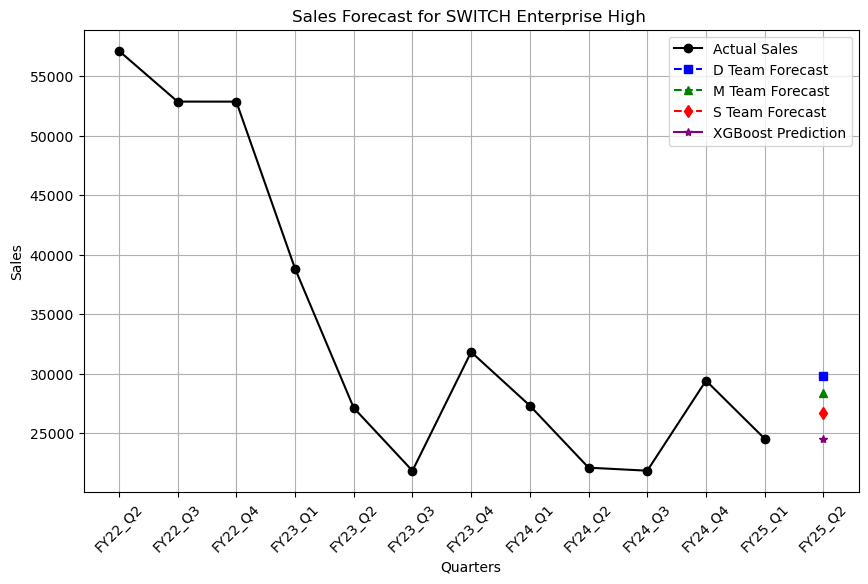

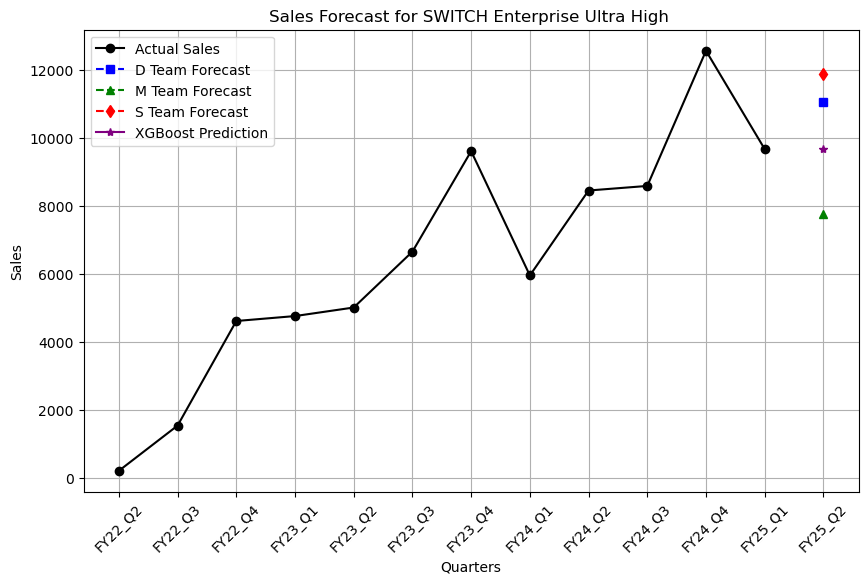

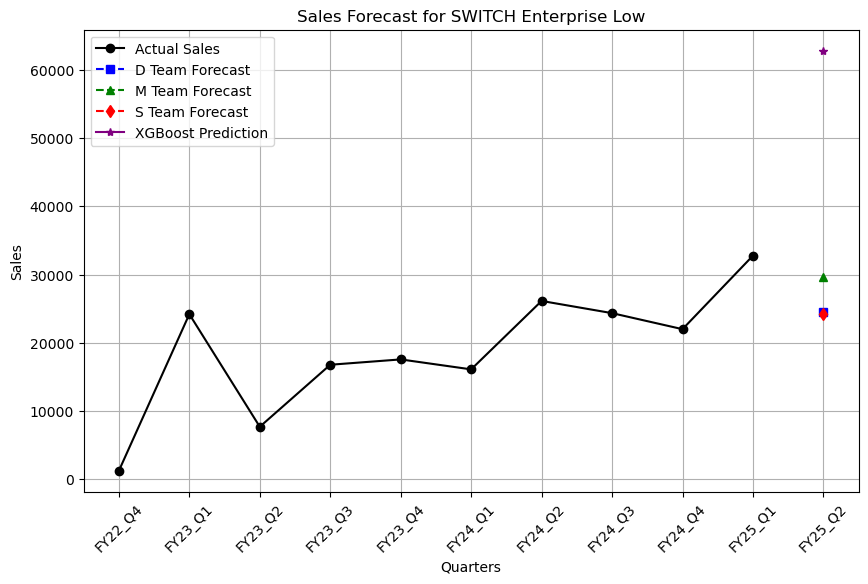

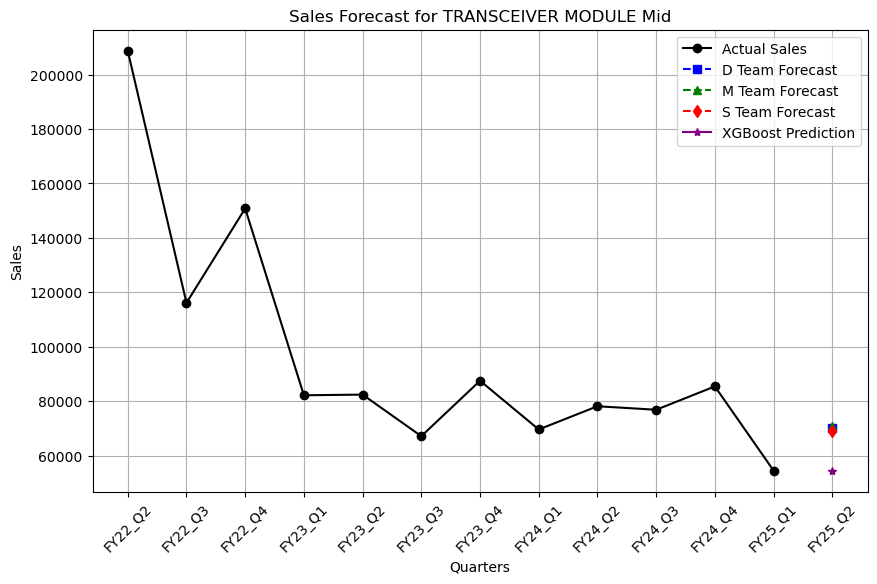

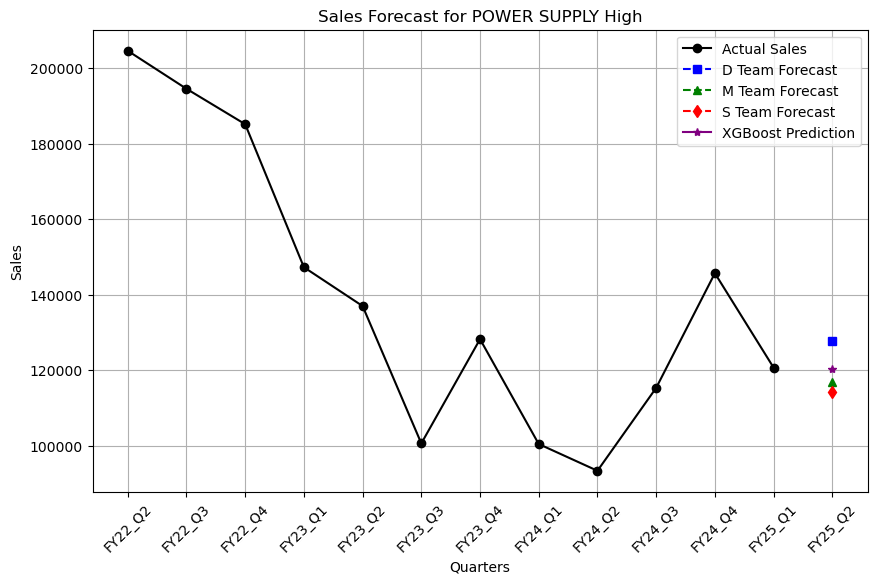

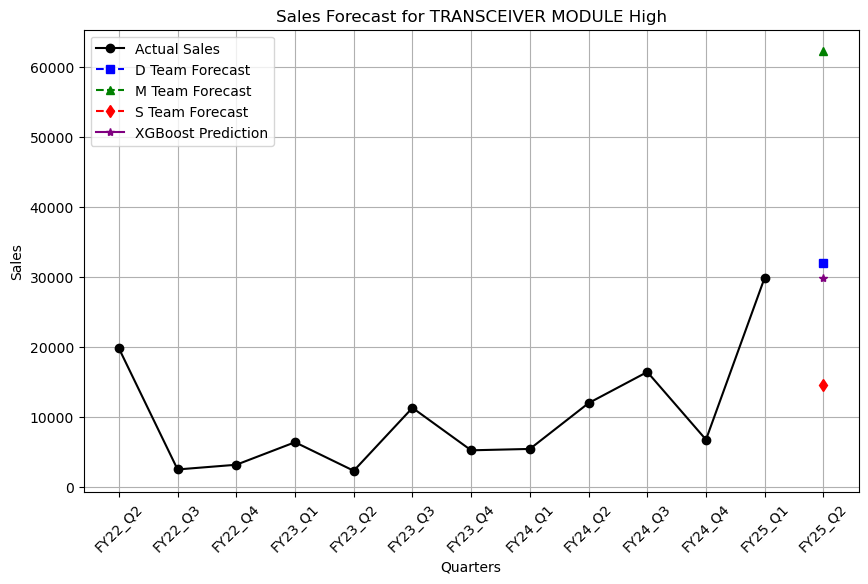

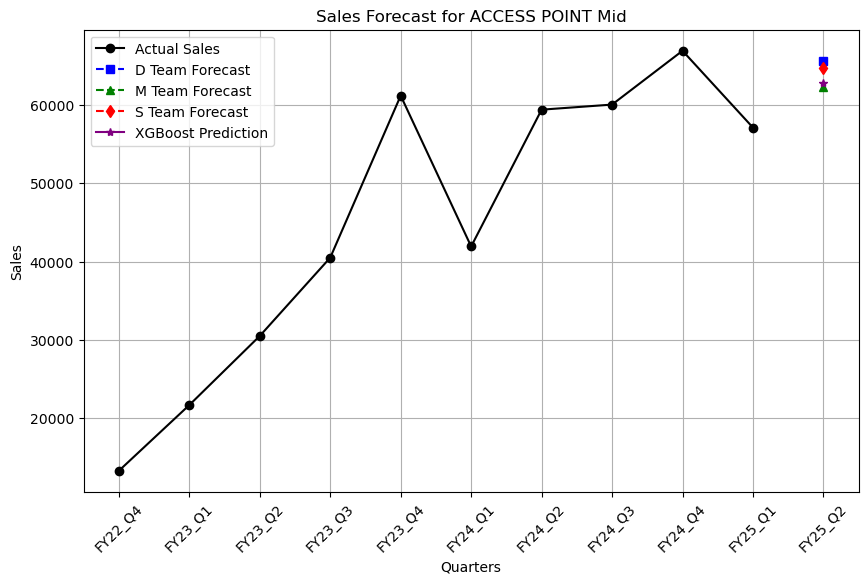

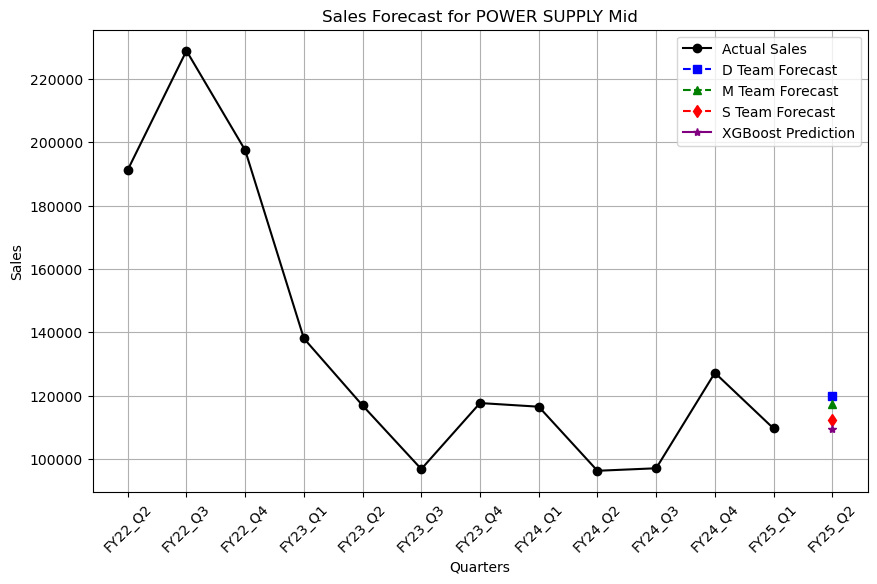

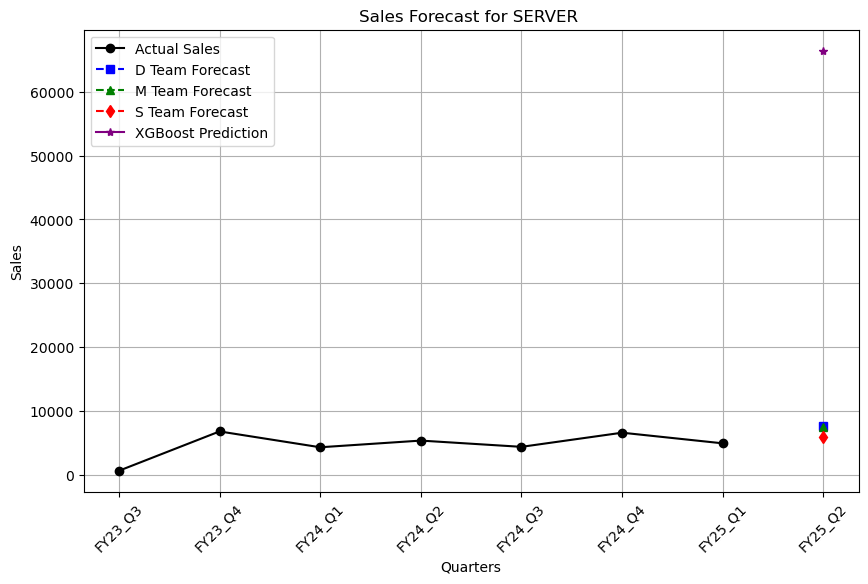

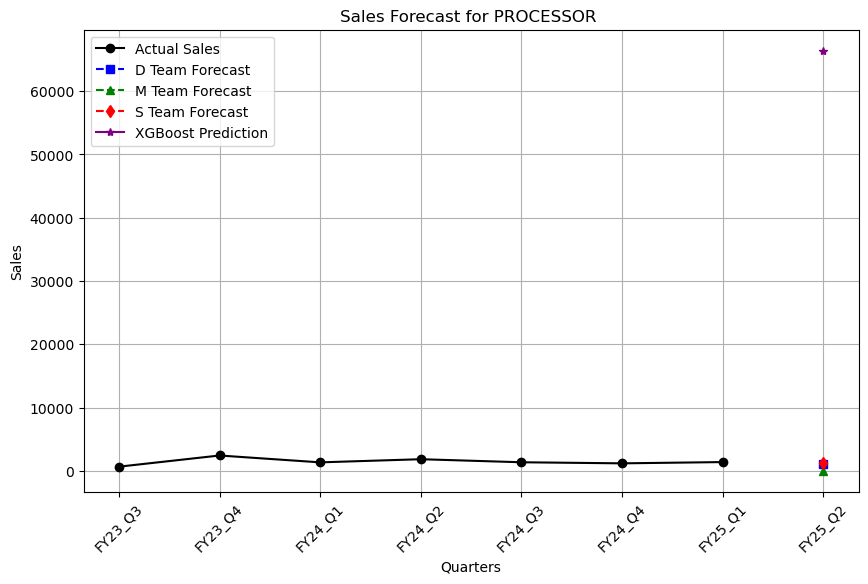

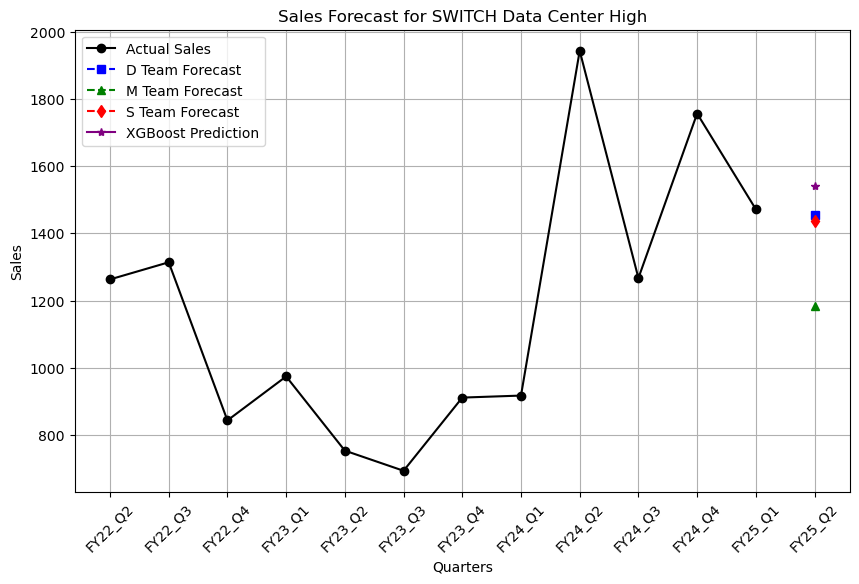

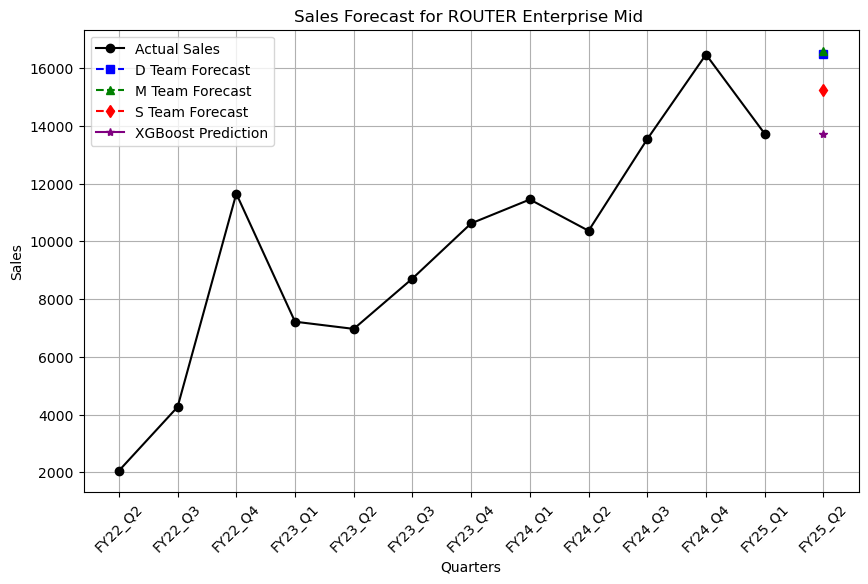

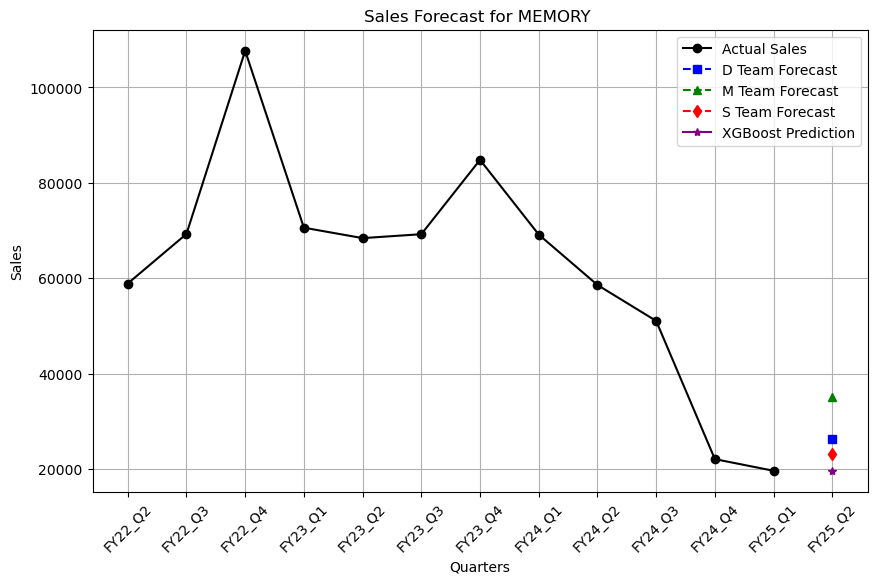

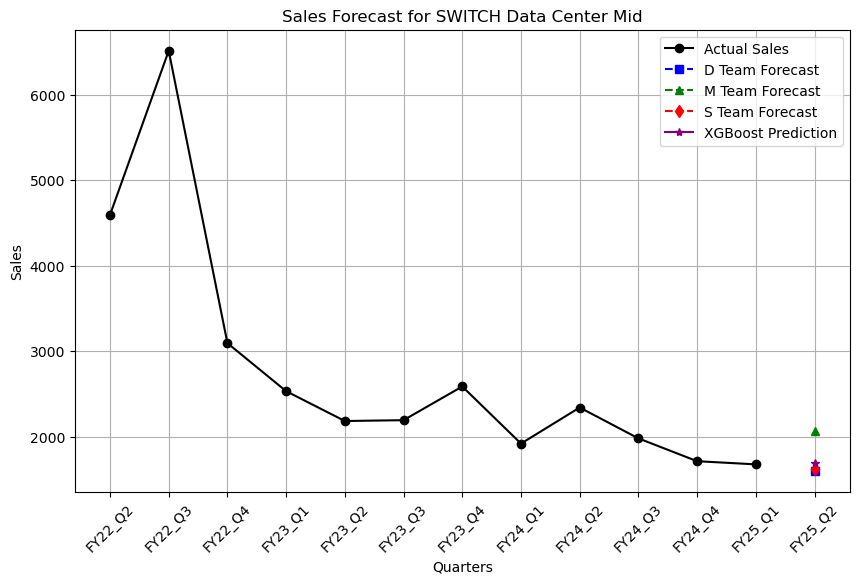

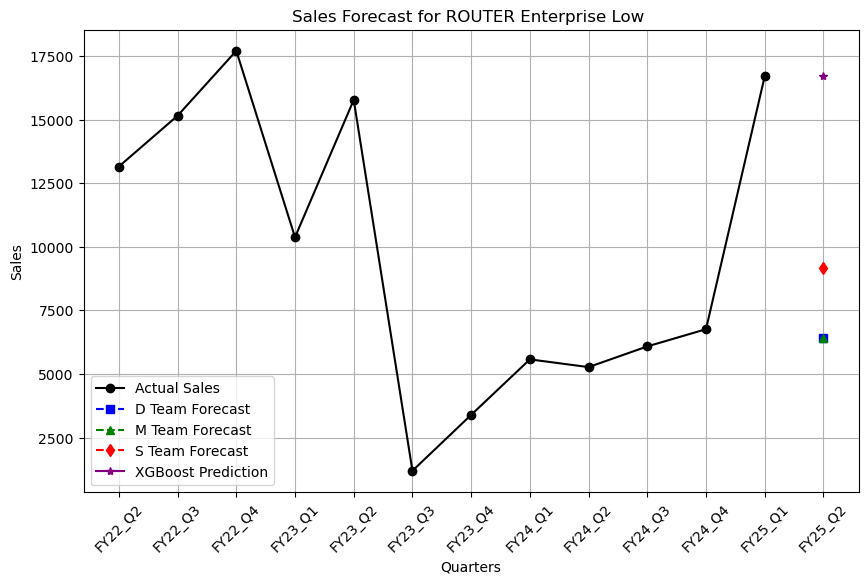

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Load dataset
df = pd.read_csv("forecasted_values.csv")

# Define columns
actual_columns = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1',
                  'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1',
                  'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']

forecast_columns = {
    "D": ['D_FY24_Q3_Forecasted', 'D_FY24_Q4_Forecasted', 'D_FY25_Q1_Forecasted', 'D_FY2025_Q2_Forecasted'],
    "M": ['M_FY24_Q3_Forecasted', 'M_FY24_Q4_Forecasted', 'M_FY25_Q1_Forecasted', 'M_FY2025_Q2_Forecasted'],
    "S": ['S_FY24_Q3_Forecasted', 'S_FY24_Q4_Forecasted', 'S_FY25_Q1_Forecasted', 'S_FY2025_Q2_Forecasted']
}

# Features: Past sales + team forecasts (excluding FY25_Q2 forecasted values)
feature_columns = actual_columns + forecast_columns["D"][:-1] + forecast_columns["M"][:-1] + forecast_columns["S"][:-1]

# Drop missing values
df_clean = df.dropna(subset=feature_columns)
X = df_clean[feature_columns]

# Train XGBoost using FY25_Q1 as a proxy for supervised learning
y = df_clean["FY25_Q1"]
xgb_model = XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X, y)

# Predict FY25_Q2 sales
df["FY25_Q2_Predicted"] = xgb_model.predict(df[feature_columns])

# Save predictions to CSV
df[["Product_Name", "FY25_Q2_Predicted"]].to_csv("FY25_Q2_Predictions.csv", index=False)

# Plot graphs for each product
for product in df["Product_Name"].unique():
    product_data = df[df["Product_Name"] == product].iloc[0]
    
    actual_sales = product_data[actual_columns].values.flatten()
    d_forecast, m_forecast, s_forecast = product_data[forecast_columns["D"][-1]], product_data[forecast_columns["M"][-1]], product_data[forecast_columns["S"][-1]]
    xgb_prediction = product_data["FY25_Q2_Predicted"]
    
    quarters = actual_columns + ["FY25_Q2"]
    all_sales = list(actual_sales) + [None]
    d_values, m_values, s_values, xgb_values = [None] * len(actual_sales) + [d_forecast], [None] * len(actual_sales) + [m_forecast], [None] * len(actual_sales) + [s_forecast], [None] * len(actual_sales) + [xgb_prediction]
    
    plt.figure(figsize=(10, 6))
    plt.plot(quarters, all_sales, label="Actual Sales", marker="o", color="black")
    plt.plot(quarters, d_values, label="D Team Forecast", linestyle="--", marker="s", color="blue")
    plt.plot(quarters, m_values, label="M Team Forecast", linestyle="--", marker="^", color="green")
    plt.plot(quarters, s_values, label="S Team Forecast", linestyle="--", marker="d", color="red")
    plt.plot(quarters, xgb_values, label="XGBoost Prediction", linestyle="-", marker="*", color="purple")
    
    plt.title(f"Sales Forecast for {product}")
    plt.xlabel("Quarters")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting auto

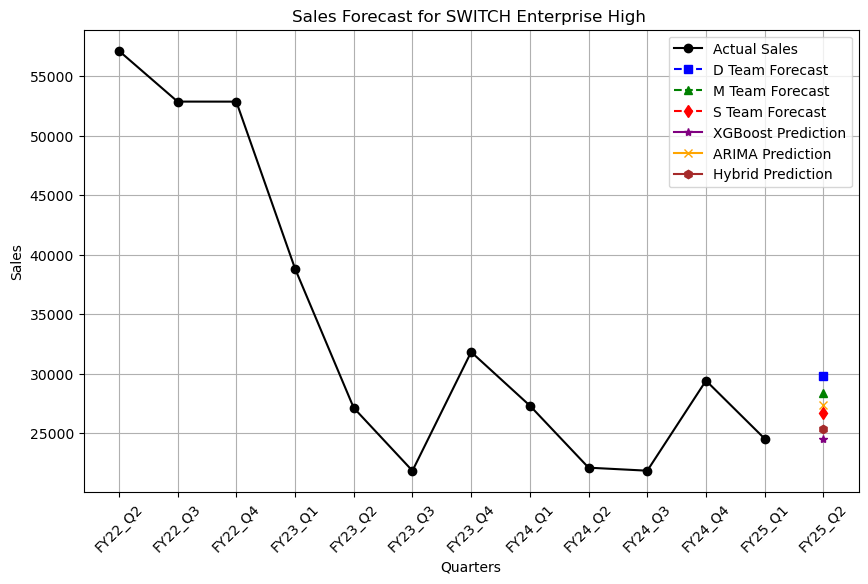

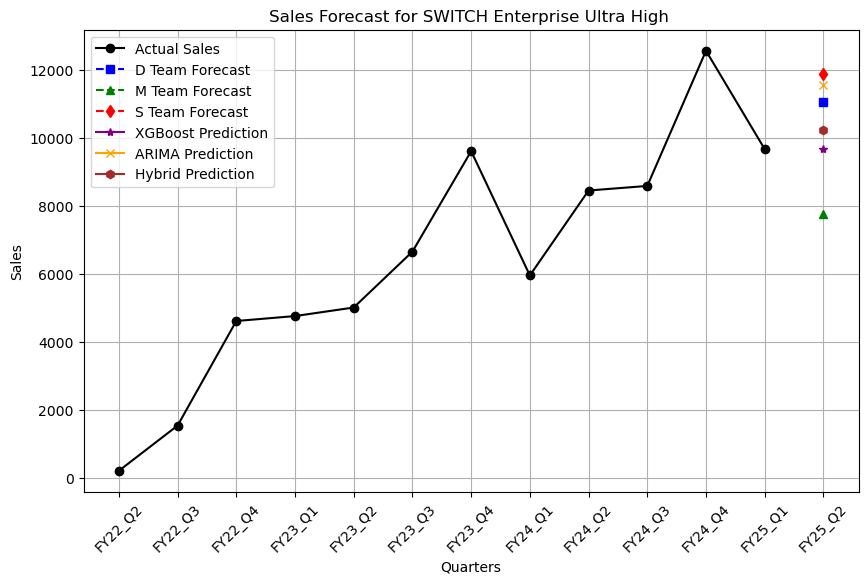

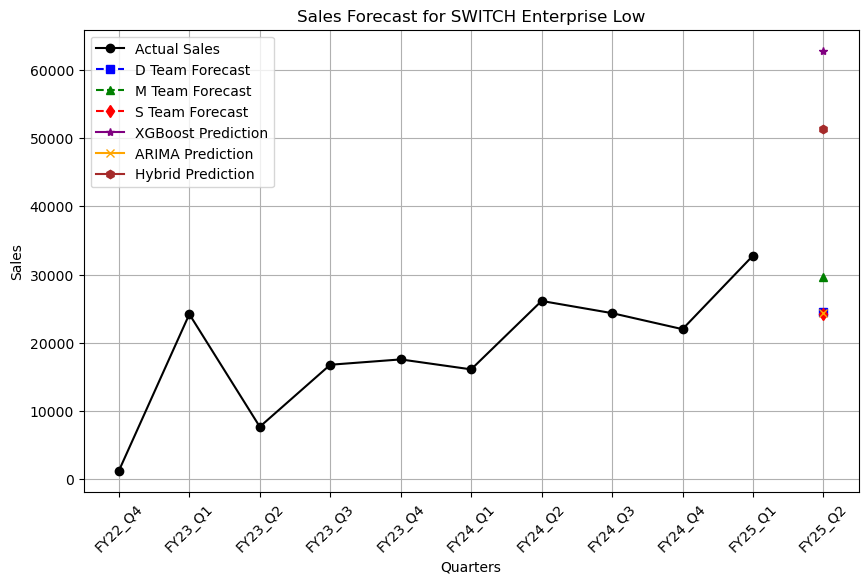

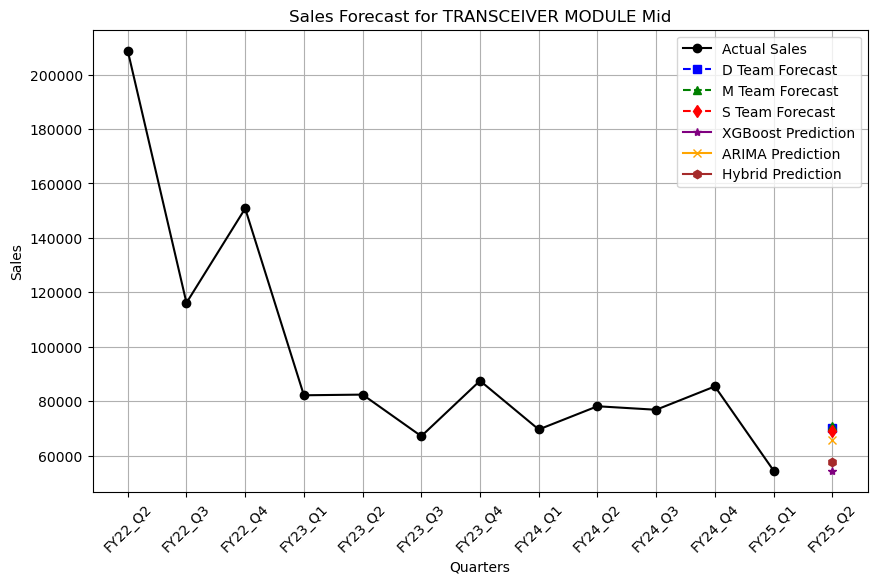

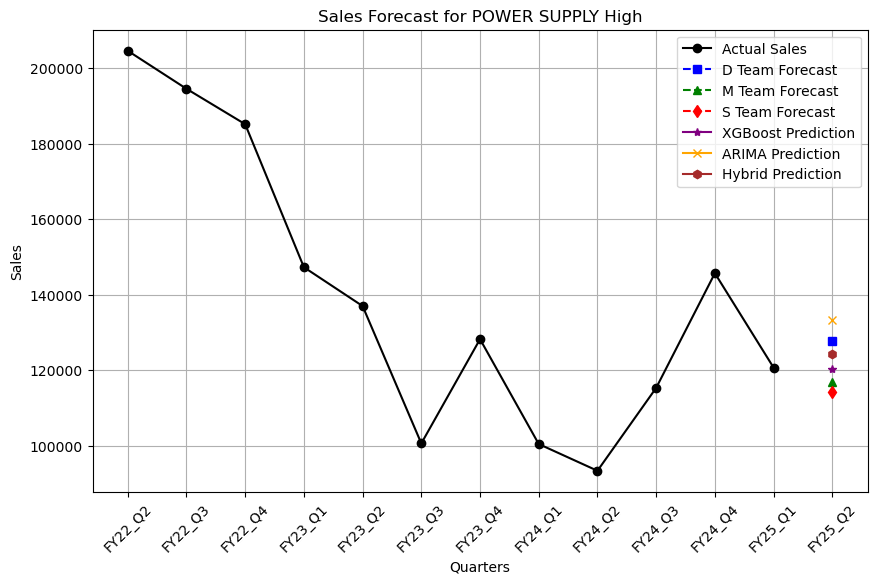

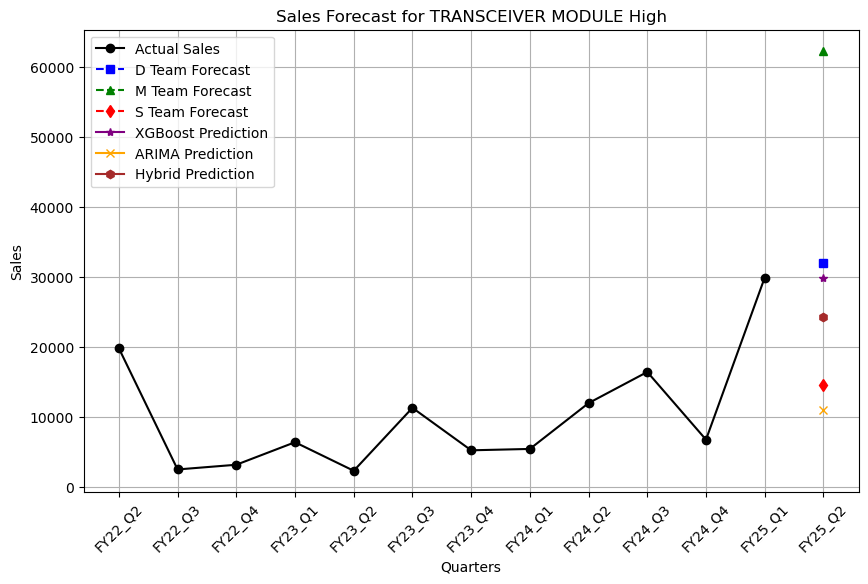

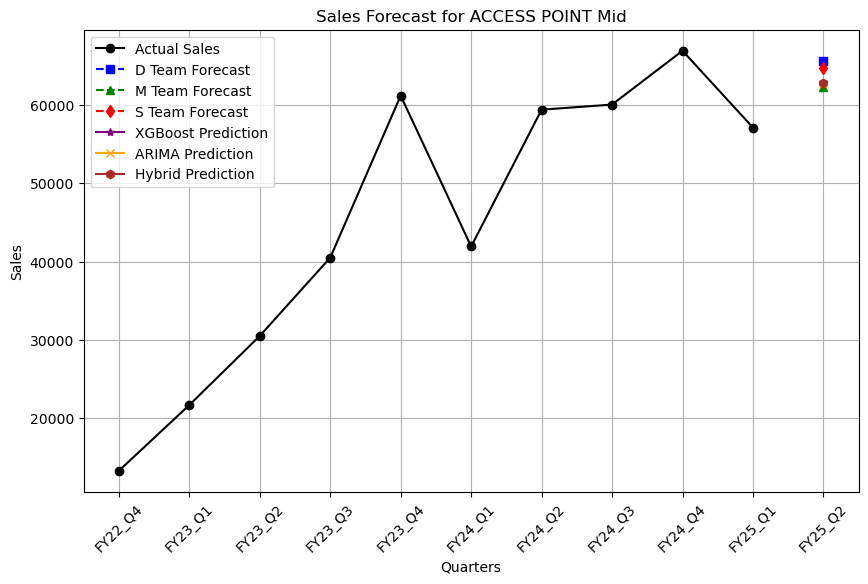

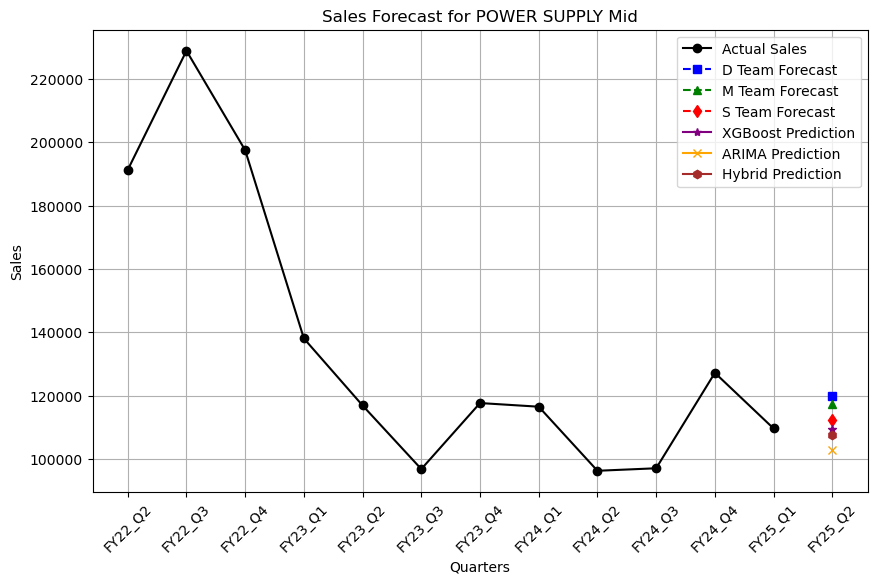

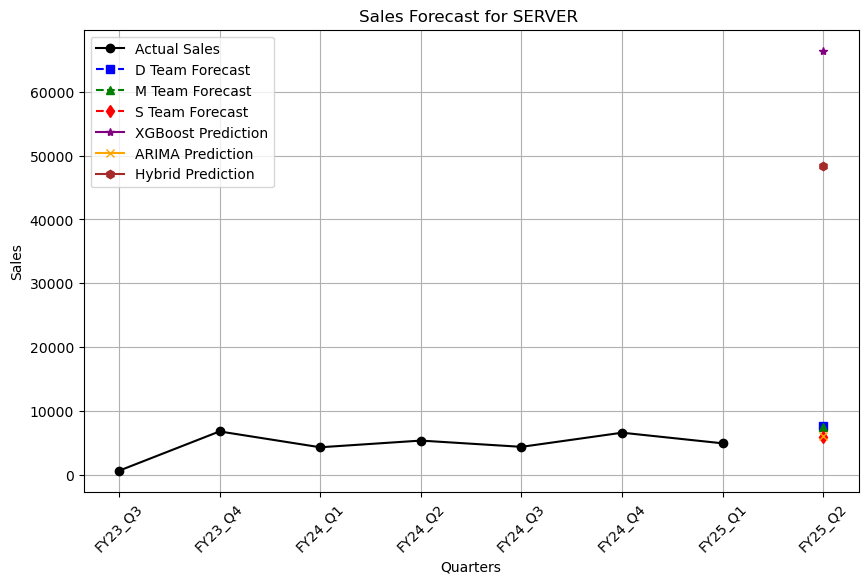

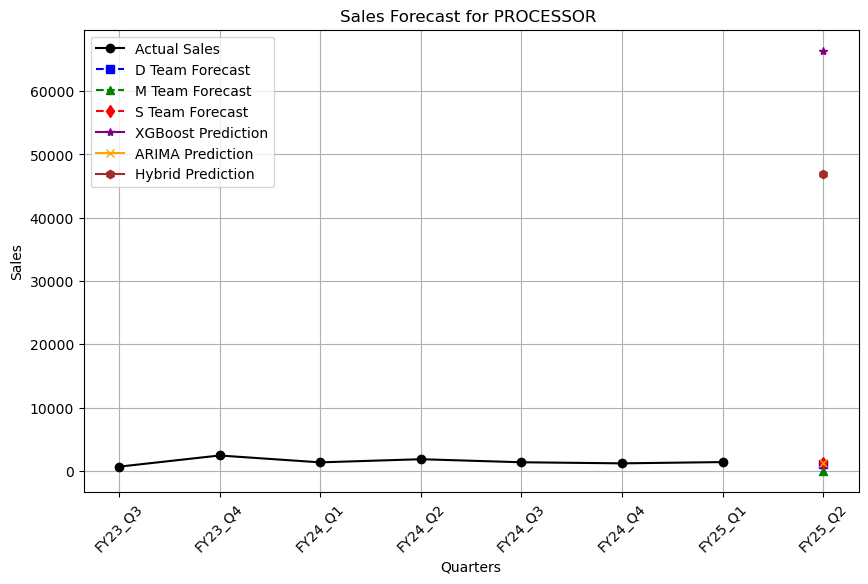

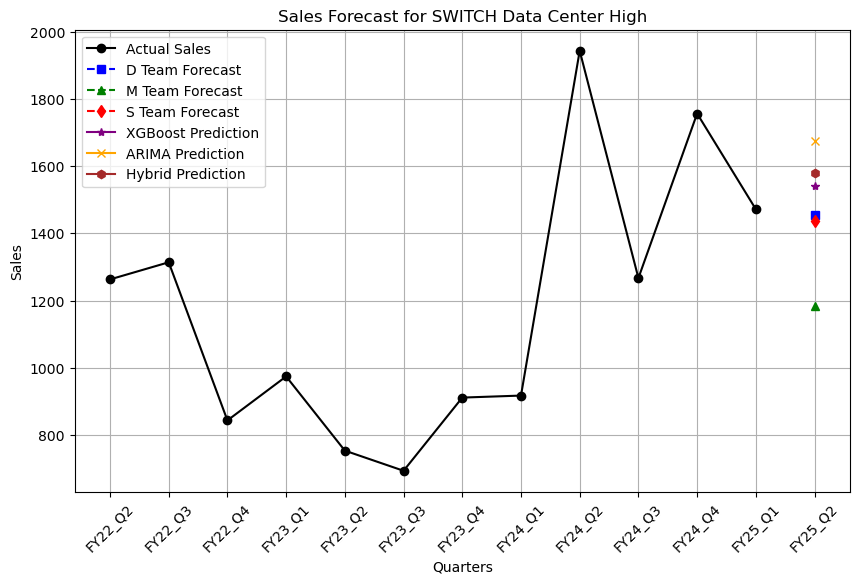

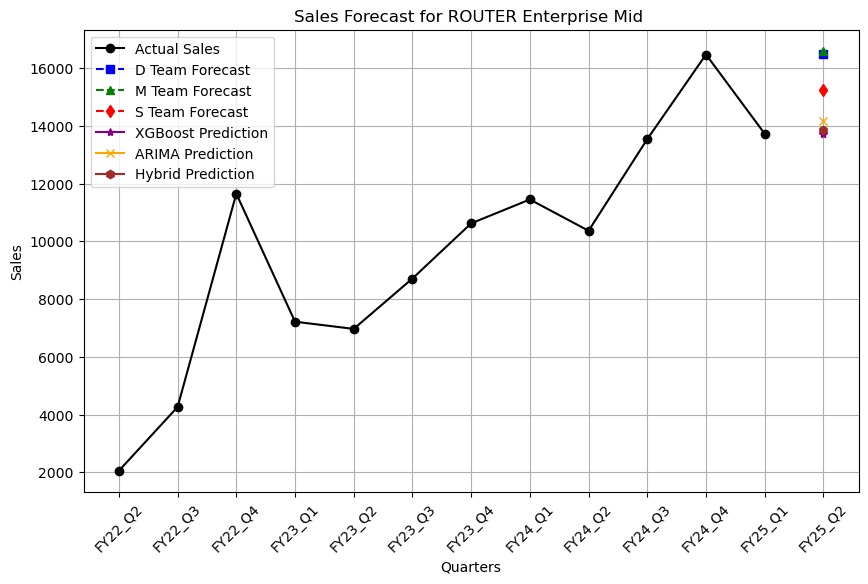

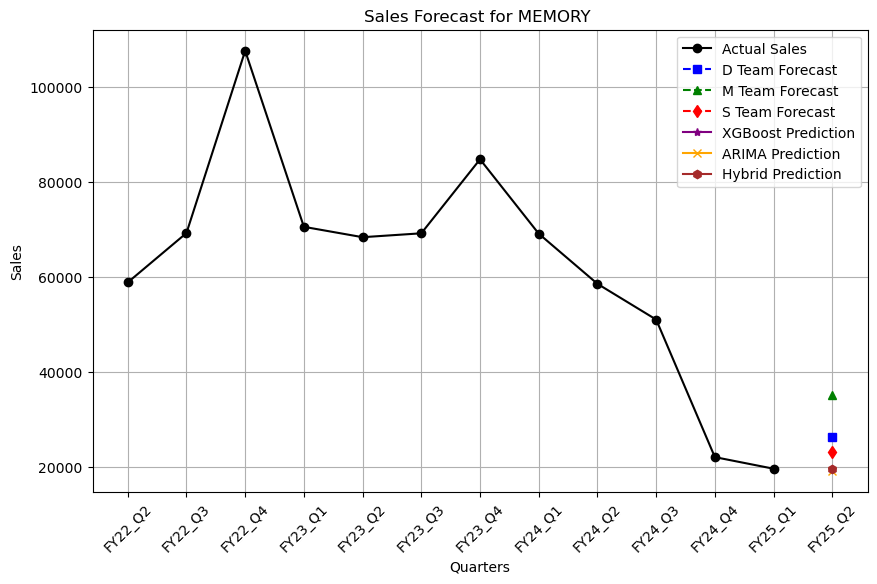

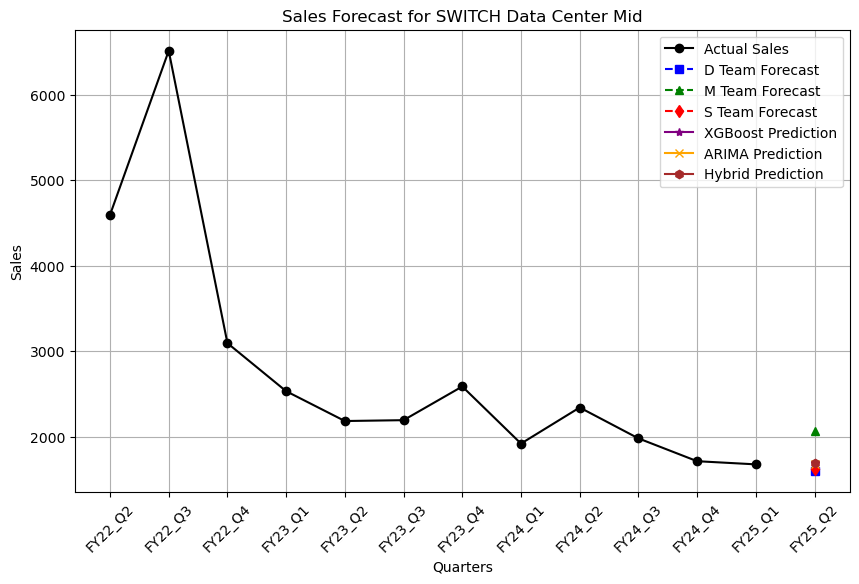

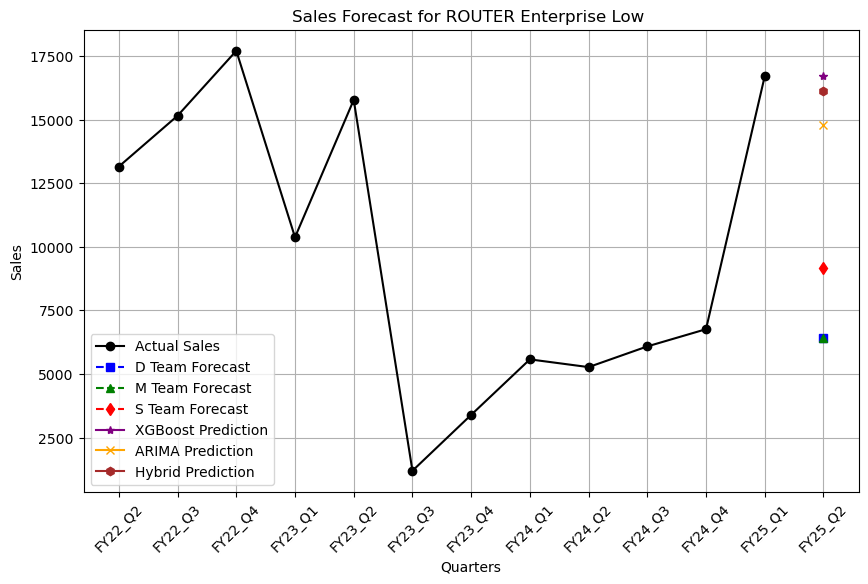

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
df = pd.read_csv("forecasted_values.csv")

# Define columns
actual_columns = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1',
                  'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1',
                  'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']

forecast_columns = {
    "D": ['D_FY24_Q3_Forecasted', 'D_FY24_Q4_Forecasted', 'D_FY25_Q1_Forecasted', 'D_FY2025_Q2_Forecasted'],
    "M": ['M_FY24_Q3_Forecasted', 'M_FY24_Q4_Forecasted', 'M_FY25_Q1_Forecasted', 'M_FY2025_Q2_Forecasted'],
    "S": ['S_FY24_Q3_Forecasted', 'S_FY24_Q4_Forecasted', 'S_FY25_Q1_Forecasted', 'S_FY2025_Q2_Forecasted']
}

# Add trend features
df["Time_Index"] = np.arange(len(df))  # Simple time index
df["Rolling_Mean"] = df[actual_columns].mean(axis=1)  # Moving average

# Features: Past sales + team forecasts (excluding FY25_Q2 forecasted values) + trend features
feature_columns = actual_columns + forecast_columns["D"][:-1] + forecast_columns["M"][:-1] + forecast_columns["S"][:-1] + ["Time_Index", "Rolling_Mean"]

# Drop missing values
df_clean = df.dropna(subset=feature_columns)
X = df_clean[feature_columns]
y = df_clean["FY25_Q1"]

# Train XGBoost with trend features
xgb_model = XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X, y)
df["FY25_Q2_XGBoost"] = xgb_model.predict(df[feature_columns])

# ARIMA Predictions (Capturing Trend)
arima_forecasts = []
for _, row in df.iterrows():
    sales_data = row[actual_columns].values.astype(float)
    try:
        model = ARIMA(sales_data, order=(1,1,1))  # Adjust order if needed
        model_fit = model.fit()
        arima_forecasts.append(model_fit.forecast(steps=1)[0])
    except:
        arima_forecasts.append(np.nan)
df["FY25_Q2_ARIMA"] = arima_forecasts

# Hybrid Model: Averaging XGBoost and ARIMA
weights = [0.7, 0.3]  # Tune weights if needed
df["FY25_Q2_Hybrid"] = (weights[0] * df["FY25_Q2_XGBoost"]) + (weights[1] * df["FY25_Q2_ARIMA"])

# Save predictions to CSV
df[["Product_Name", "FY25_Q2_XGBoost", "FY25_Q2_ARIMA", "FY25_Q2_Hybrid"]].to_csv("FY25_Q2_Predictions_Enhanced.csv", index=False)

# Plot graphs for each product
for product in df["Product_Name"].unique():
    product_data = df[df["Product_Name"] == product].iloc[0]
    
    actual_sales = product_data[actual_columns].values.flatten()
    d_forecast, m_forecast, s_forecast = product_data[forecast_columns["D"][-1]], product_data[forecast_columns["M"][-1]], product_data[forecast_columns["S"][-1]]
    xgb_prediction = product_data["FY25_Q2_XGBoost"]
    arima_prediction = product_data["FY25_Q2_ARIMA"]
    hybrid_prediction = product_data["FY25_Q2_Hybrid"]
    
    quarters = actual_columns + ["FY25_Q2"]
    all_sales = list(actual_sales) + [None]
    d_values, m_values, s_values = [None] * len(actual_sales) + [d_forecast], [None] * len(actual_sales) + [m_forecast], [None] * len(actual_sales) + [s_forecast]
    xgb_values, arima_values, hybrid_values = [None] * len(actual_sales) + [xgb_prediction], [None] * len(actual_sales) + [arima_prediction], [None] * len(actual_sales) + [hybrid_prediction]
    
    plt.figure(figsize=(10, 6))
    plt.plot(quarters, all_sales, label="Actual Sales", marker="o", color="black")
    plt.plot(quarters, d_values, label="D Team Forecast", linestyle="--", marker="s", color="blue")
    plt.plot(quarters, m_values, label="M Team Forecast", linestyle="--", marker="^", color="green")
    plt.plot(quarters, s_values, label="S Team Forecast", linestyle="--", marker="d", color="red")
    plt.plot(quarters, xgb_values, label="XGBoost Prediction", linestyle="-", marker="*", color="purple")
    plt.plot(quarters, arima_values, label="ARIMA Prediction", linestyle="-", marker="x", color="orange")
    plt.plot(quarters, hybrid_values, label="Hybrid Prediction", linestyle="-", marker="h", color="brown")
    
    plt.title(f"Sales Forecast for {product}")
    plt.xlabel("Quarters")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


In [9]:
import pandas as pd

# Load original dataset
df_original = pd.read_csv("forecasted_values.csv")

# Load predictions
df_predictions = pd.read_csv("FY25_Q2_Predictions_Enhanced.csv")

# Merge datasets on "Product_Name"
df_combined = df_original.merge(df_predictions, on="Product_Name", how="left")

# Save the updated dataset with predictions
df_combined.to_csv("forecasted_values_with_predictions.csv", index=False)

print("Merged dataset saved as 'forecasted_values_with_predictions.csv'")


Merged dataset saved as 'forecasted_values_with_predictions.csv'


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
df = pd.read_csv('forecasted_values.csv')

# Define forecast columns
forecast_cols = ['D_FY2025_Q2_Forecasted', 'M_FY2025_Q2_Forecasted', 'S_FY2025_Q2_Forecasted']
model_preds = ['ARIMA_Pred', 'XGBoost_Pred', 'Hybrid_Pred']

# Ensure necessary columns exist
df = df[['Product_Name'] + forecast_cols + model_preds]

# Error metrics calculation
def calculate_metrics(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted))
    }

# Store results
results = []

# Loop through each product
for index, row in df.iterrows():
    product = row['Product_Name']
    
    # Get actual values (forecasted by teams)
    actual_values = row[forecast_cols].values
    
    # Get model predictions
    arima_pred = row['ARIMA_Pred']
    xgb_pred = row['XGBoost_Pred']
    hybrid_pred = row['Hybrid_Pred']
    
    # Compute errors
    arima_error = calculate_metrics(actual_values, [arima_pred] * len(actual_values))
    xgb_error = calculate_metrics(actual_values, [xgb_pred] * len(actual_values))
    hybrid_error = calculate_metrics(actual_values, [hybrid_pred] * len(actual_values))
    
    # Determine best model
    best_model = min([(arima_error['RMSE'], 'ARIMA'), (xgb_error['RMSE'], 'XGBoost'), (hybrid_error['RMSE'], 'Hybrid')])[1]
    
    # Save results
    results.append([product, arima_pred, xgb_pred, hybrid_pred, arima_error['RMSE'], xgb_error['RMSE'], hybrid_error['RMSE'], best_model])
    
    # Plot comparison
    plt.figure(figsize=(10, 5))
    plt.plot(forecast_cols, actual_values, 'o-', label='Team Forecasts', color='blue')
    plt.axhline(y=arima_pred, color='r', linestyle='--', label='ARIMA')
    plt.axhline(y=xgb_pred, color='g', linestyle='--', label='XGBoost')
    plt.axhline(y=hybrid_pred, color='orange', linestyle='--', label='Hybrid')
    plt.title(f'FY25_Q2 Forecast Comparison for {product}')
    plt.legend()
    plt.show()

# Convert to DataFrame and save results
results_df = pd.DataFrame(results, columns=['Product_Name', 'ARIMA_Pred', 'XGBoost_Pred', 'Hybrid_Pred', 'ARIMA_RMSE', 'XGBoost_RMSE', 'Hybrid_RMSE', 'Best_Model'])
results_df.to_csv('/mnt/data/forecast_comparison_results.csv', index=False)

print("Results saved to 'forecast_comparison_results.csv'")


KeyError: "['ARIMA_Pred', 'XGBoost_Pred', 'Hybrid_Pred'] not in index"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
df = pd.read_csv('forecasted_values.csv')

# Define forecast columns
forecast_cols = ['D_FY2025_Q2_Forecasted', 'M_FY2025_Q2_Forecasted', 'S_FY2025_Q2_Forecasted']

# Ensure necessary columns exist
if 'ARIMA_Pred' not in df.columns or 'XGBoost_Pred' not in df.columns or 'Hybrid_Pred' not in df.columns:
    print("Error: Missing predicted values in dataset. Adding them now...")
    df['ARIMA_Pred'] = np.nan  # Placeholder
    df['XGBoost_Pred'] = np.nan  # Placeholder
    df['Hybrid_Pred'] = np.nan  # Placeholder
    df.to_csv('forecasted_values.csv', index=False)
    print("Updated dataset saved with placeholders for predictions.")
    exit()

# Error metrics calculation
def calculate_metrics(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted))
    }

# Store results
results = []

# Loop through each product
for index, row in df.iterrows():
    product = row['Product_Name']
    
    # Get actual values (forecasted by teams)
    actual_values = row[forecast_cols].values
    
    # Get model predictions
    arima_pred = row['ARIMA_Pred']
    xgb_pred = row['XGBoost_Pred']
    hybrid_pred = row['Hybrid_Pred']
    
    # Compute errors
    arima_error = calculate_metrics(actual_values, [arima_pred] * len(actual_values))
    xgb_error = calculate_metrics(actual_values, [xgb_pred] * len(actual_values))
    hybrid_error = calculate_metrics(actual_values, [hybrid_pred] * len(actual_values))
    
    # Determine best model
    best_model = min([(arima_error['RMSE'], 'ARIMA'), (xgb_error['RMSE'], 'XGBoost'), (hybrid_error['RMSE'], 'Hybrid')])[1]
    
    # Save results
    results.append([product, arima_pred, xgb_pred, hybrid_pred, arima_error['RMSE'], xgb_error['RMSE'], hybrid_error['RMSE'], best_model])
    
    # Plot comparison
    plt.figure(figsize=(10, 5))
    plt.plot(forecast_cols, actual_values, 'o-', label='Team Forecasts', color='blue')
    plt.axhline(y=arima_pred, color='r', linestyle='--', label='ARIMA')
    plt.axhline(y=xgb_pred, color='g', linestyle='--', label='XGBoost')
    plt.axhline(y=hybrid_pred, color='orange', linestyle='--', label='Hybrid')
    plt.title(f'FY25_Q2 Forecast Comparison for {product}')
    plt.legend()
    plt.show()

# Convert to DataFrame and save results
results_df = pd.DataFrame(results, columns=['Product_Name', 'ARIMA_Pred', 'XGBoost_Pred', 'Hybrid_Pred', 'ARIMA_RMSE', 'XGBoost_RMSE', 'Hybrid_RMSE', 'Best_Model'])
results_df.to_csv('forecast_comparison_results.csv', index=False)

print("Results saved to 'forecast_comparison_results.csv'")


ValueError: Input contains NaN.